# MVTec AD - Surface Classification
**Models:** YOLO11n-cls | EfficientNet-B0 | MobileNetV3-Small

**Classes:** Carpet | Grid | Leather | Tile | Wood | Unknown / Rejected

**Pipeline:** Dataset -> Augmentation -> Training -> Evaluation -> Comparison -> Interactive Upload Inference



User Guide:

- Ensure that you have MVTec Suppted format folders, if you want to train the model on different dataset.

- IF you decide to train with existing texture classes (grid, tile, leather, wood and carpet), specify your dataset directory in "ROOT_PATH"

- Run all cells if you want to train and evaluate.

- Run everyhting except model training cells, if you want to just evaluate, in that case, ensure that you have all three models loaded to your drive as dataset_root/checkpoints.

- After training the model, choose the best performing model and paste that model in to github models folder:

Surface-Anomaly-Detection-System/models

Replace new model with the existing model in the folder and rename the modename_best.pt -> modelname.pt

# Section 1 - Environment Setup and Dependencies

## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Install Dependencies

In [2]:
!pip install ultralytics timm torchmetrics seaborn scikit-learn matplotlib pandas numpy pillow tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.8 MB/s eta 0:00:00


## Import Libraries and Set Seed

Loads all required packages, sets random seeds for reproducibility, and detects the available compute device.

In [3]:
import os                          # File and directory path operations (saving results, checking paths)
import json                        # Reading/writing JSON files (class config, idx mappings)
import copy                        # Deep-copying models during training (e.g. saving best weights)
import time                        # Measuring training time per epoch
import random                      # Random sampling and shuffling (dataset splits, augmentation)
import warnings                    # Suppressing non-critical warnings for cleaner output
import numpy as np                 # Numerical arrays and math operations (probs, labels, metrics)
import pandas as pd                # DataFrames for building and saving summary tables/CSVs
import matplotlib.pyplot as plt    # Plotting charts, confusion matrices, and summary tables
import matplotlib.gridspec as gridspec  # Fine-grained subplot layout control for complex figures
import seaborn as sns              # Styled heatmaps for confusion matrix visualizations
from pathlib import Path           # Object-oriented file path handling (cleaner than os.path)
from PIL import Image              # Loading and converting images (RGB, resizing for inference)
from tqdm import tqdm              # Progress bars during training loops and inference
from collections import defaultdict  # Auto-initializing dicts for grouping results by class

import torch                       # Core PyTorch framework for tensor ops and autograd
import torch.nn as nn              # Neural network layers, loss functions (BCEWithLogitsLoss)
import torch.optim as optim        # Optimizers (Adam, SGD) for model training
from torch.utils.data import Dataset, DataLoader  # Custom dataset class and batched data loading
import torchvision.transforms as T  # Image preprocessing pipelines (resize, normalize, augment)
import torchvision.models as models  # Pretrained model architectures (ResNet, MobileNet, etc.)
from torchmetrics import Accuracy, F1Score, Precision, Recall, ConfusionMatrix, AUROC  # GPU-compatible metric computation during training

import timm                        # Large library of pretrained vision models (EfficientNet-B0)
from ultralytics import YOLO       # YOLO model loading, training, and inference

warnings.filterwarnings('ignore')  # Suppress deprecation and runtime warnings for cleaner output

SEED = 42
random.seed(SEED)                  # Seed Python's random module
np.random.seed(SEED)               # Seed NumPy for reproducible array operations
torch.manual_seed(SEED)            # Seed PyTorch CPU ops
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)  # Seed all GPUs for fully reproducible training

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')  # Confirm which GPU is being used

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cpu


# Section 2 - Configuration

In [4]:
# ----------------------------------------------------------------
# ROOT PATH - set this to your dataset folder in Drive
# ----------------------------------------------------------------
ROOT_PATH = '/content/drive/MyDrive/Colab Notebooks/ICT304/object_class'
# ----------------------------------------------------------------

CHECKPOINT_DIR = os.path.join(ROOT_PATH, 'checkpoints')
RESULTS_DIR    = os.path.join(ROOT_PATH, 'results')
CLASSES_JSON   = os.path.join(ROOT_PATH, 'classes.json')

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,    exist_ok=True)

SURFACE_CLASSES = ['carpet', 'grid', 'leather', 'tile', 'wood']
UNKNOWN_CLASS   = 'unknown'
CONFIDENCE_THRESHOLD = 0.80

classes_data = {
    'classes': SURFACE_CLASSES,
    'unknown_class': UNKNOWN_CLASS,
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'num_classes': len(SURFACE_CLASSES),
    'class_to_idx': {cls: i for i, cls in enumerate(SURFACE_CLASSES)},
    'idx_to_class': {i: cls for i, cls in enumerate(SURFACE_CLASSES)}
}

with open(CLASSES_JSON, 'w') as f:
    json.dump(classes_data, f, indent=2)

print('Classes JSON saved to:', CLASSES_JSON)
print(json.dumps(classes_data, indent=2))


Classes JSON saved to: /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/classes.json
{
  "classes": [
    "carpet",
    "grid",
    "leather",
    "tile",
    "wood"
  ],
  "unknown_class": "unknown",
  "confidence_threshold": 0.8,
  "num_classes": 5,
  "class_to_idx": {
    "carpet": 0,
    "grid": 1,
    "leather": 2,
    "tile": 3,
    "wood": 4
  },
  "idx_to_class": {
    "0": "carpet",
    "1": "grid",
    "2": "leather",
    "3": "tile",
    "4": "wood"
  }
}


## Training Hyperparameters

In [5]:
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_EPOCHS   = 30
NUM_WORKERS  = 2
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.15


YOLO_LR      = 0.001
EFFNET_LR    = 1e-4
MOBILENET_LR = 1e-4

WEIGHT_DECAY = 1e-4
SCHEDULER_PATIENCE = 4
EARLY_STOP_PATIENCE = 13


# Section 3 - Dataset Structure and MVTec Paths

## Extract Dataset Archives

Copies and extracts per-class `.tar.xz` archives from Google Drive to local disk for faster I/O during training.

In [6]:
import tarfile
import shutil
import os

#------------------------------------------------------------------
# Set this path also to your dataset folder
#------------------------------------------------------------------
DRIVE_DATA  = ROOT_PATH
LOCAL_DATA  = '/content/data'

os.makedirs(LOCAL_DATA, exist_ok=True)

for cls in SURFACE_CLASSES:
    target        = os.path.join(LOCAL_DATA, cls)
    archive_drive = os.path.join(DRIVE_DATA, f'{cls}.tar.xz')
    archive_local = os.path.join(LOCAL_DATA, f'{cls}.tar.xz')

    # Already extracted locally - nothing to do
    if os.path.isdir(target):
        print(f'{cls} - already extracted, skipping')
        continue

    # Archive missing from Drive - check if raw folder exists and compress it first
    if not os.path.exists(archive_drive):
        raw_folder = os.path.join(DRIVE_DATA, cls)
        if not os.path.isdir(raw_folder):
            print(f'{cls} - neither archive nor raw folder found in Drive, skipping')
            continue

        print(f'{cls} - no archive found, compressing raw folder in Drive...')
        tmp_archive = archive_drive + '.tmp'
        with tarfile.open(tmp_archive, 'w:xz') as tar:
            tar.add(raw_folder, arcname=cls)
        os.rename(tmp_archive, archive_drive)
        print(f'{cls} - compression done, archive saved to Drive')

    # Copy archive from Drive to local disk
    print(f'{cls} - copying archive from Drive...')
    shutil.copy2(archive_drive, archive_local)

    # Extract locally
    print(f'{cls} - extracting...')
    with tarfile.open(archive_local, 'r:xz') as tar:
        tar.extractall(LOCAL_DATA)

    # Delete local archive to free Colab disk space
    os.remove(archive_local)
    print(f'{cls} - done, local archive deleted to save space')

ROOT_PATH = LOCAL_DATA
print(f'\nAll done. ROOT_PATH set to: {ROOT_PATH}')

carpet - copying archive from Drive...
carpet - extracting...
carpet - done, local archive deleted to save space
grid - copying archive from Drive...
grid - extracting...
grid - done, local archive deleted to save space
leather - copying archive from Drive...
leather - extracting...
leather - done, local archive deleted to save space
tile - copying archive from Drive...
tile - extracting...
tile - done, local archive deleted to save space
wood - copying archive from Drive...
wood - extracting...
wood - done, local archive deleted to save space

All done. ROOT_PATH set to: /content/data


## Dataset Population and Equalization

Augments training data by copying a proportion of defect images from the test split, then equalizes class counts by duplicating good samples up to a per-class cap.

In [7]:
import shutil
import math

def get_all_image_paths(root: str, surface_classes: list):
    valid_exts = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
    samples = []
    for idx, cls in enumerate(surface_classes):
        cls_dir = os.path.join(root, cls, 'train')
        if not os.path.isdir(cls_dir):
            continue
        for subdir, _, files in os.walk(cls_dir):
            for fname in files:
                if os.path.splitext(fname)[1].lower() in valid_exts:
                    samples.append((os.path.join(subdir, fname), idx))
    return samples

def populate_and_equalize_v2(root: str, surface_classes: list, defect_map: dict,
                              class_caps: dict, max_good_copies: int = 20):
    valid_exts = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
    train_only_paths = set()

    for cls in surface_classes:
        cap = class_caps.get(cls, 310)

        all_now = get_all_image_paths(root, surface_classes)
        current = sum(1 for _, l in all_now if surface_classes[l] == cls)
        remaining_budget = cap - current

        if remaining_budget <= 0:
            print(f'  {cls:10s}: already at {current}, skipping defect copy')
            continue

        defects = defect_map.get(cls, [])
        if not defects:
            continue

        # --- Proportional-ratio sampling ---
        available = {}
        for defect in defects:
            src_dir = os.path.join(root, cls, 'test', defect)
            if not os.path.isdir(src_dir):
                available[defect] = 0
                continue
            imgs = sorted([f for f in os.listdir(src_dir)
                           if os.path.splitext(f)[1].lower() in valid_exts])
            available[defect] = math.ceil(len(imgs) * 0.5)

        total_available = sum(available.values()) or 1
        budgets = {
            defect: math.floor(remaining_budget * (avail / total_available))
            for defect, avail in available.items()
        }
        leftover = remaining_budget - sum(budgets.values())
        if leftover > 0:
            budgets[max(available, key=available.get)] += leftover
        # -----------------------------------

        for defect in defects:
            src_dir = os.path.join(root, cls, 'test', defect)
            if not os.path.isdir(src_dir):
                continue

            dst_dir = os.path.join(root, cls, 'train', defect)
            os.makedirs(dst_dir, exist_ok=True)

            images = sorted([f for f in os.listdir(src_dir)
                             if os.path.splitext(f)[1].lower() in valid_exts])

            half           = images[:math.ceil(len(images) * 0.5)]
            budget_for_def = budgets.get(defect, 0)
            to_copy        = half[:min(len(half), budget_for_def)]

            copied = 0
            for fname in to_copy:
                src_path = os.path.join(src_dir, fname)
                stem, ext = os.path.splitext(fname)
                dst_name  = f'{stem}_c0{ext}'
                dst_path  = os.path.join(dst_dir, dst_name)
                shutil.copy2(src_path, dst_path)
                train_only_paths.add(os.path.realpath(dst_path))
                copied += 1

            print(f'  {cls}/{defect}: {len(images)} total, {copied} copied (proportional budget={budget_for_def})')

    # recount
    all_samples = get_all_image_paths(root, surface_classes)
    label_counts = defaultdict(int)
    for _, lbl in all_samples:
        label_counts[surface_classes[lbl]] += 1

    print('\nAfter defect population:')
    for cls, cnt in label_counts.items():
        print(f'  {cls:10s}: {cnt}')

    # equalize with good copies up to cap
    target = min(min(class_caps.values()), min(label_counts.values()) + max_good_copies)
    print(f'\nTarget for equalization: {target}')

    for cls in surface_classes:
        current = label_counts[cls]
        cap     = class_caps.get(cls, 310)
        needed  = min(cap, target) - current

        if needed <= 0:
            print(f'  {cls:10s}: {current}, no good copies needed')
            continue

        copies   = min(needed, max_good_copies)
        good_dir = os.path.join(root, cls, 'train', 'good')
        sources  = sorted([os.path.join(good_dir, f) for f in os.listdir(good_dir)
                           if os.path.splitext(f)[1].lower() in valid_exts])

        dst_dir = os.path.join(root, cls, 'train', 'equalizer')
        os.makedirs(dst_dir, exist_ok=True)

        for k in range(copies):
            src_path = sources[k % len(sources)]
            fname    = os.path.splitext(os.path.basename(src_path))[0]
            dst_path = os.path.join(dst_dir, f'{fname}_eq{k}.png')
            shutil.copy2(src_path, dst_path)
            train_only_paths.add(os.path.realpath(dst_path))  # lock the copy
            train_only_paths.add(os.path.realpath(src_path))  # lock the source original

        print(f'  {cls:10s}: {current} -> {current + copies} (added {copies} good copies)')

    all_samples = get_all_image_paths(root, surface_classes)
    label_counts = defaultdict(int)
    for _, lbl in all_samples:
        label_counts[surface_classes[lbl]] += 1

    print('\nFinal samples per class:')
    for cls, cnt in label_counts.items():
        good = sum(1 for p, l in all_samples if surface_classes[l] == cls and '/good/' in p)
        bad  = sum(1 for p, l in all_samples if surface_classes[l] == cls and '/good/' not in p)
        print(f'  {cls:10s}: total={cnt}  good={good}  bad={bad}')
    print(f'Total: {len(all_samples)}')

    return all_samples, train_only_paths

DEFECT_MAP = {
    'carpet':  ['color', 'cut', 'hole', 'metal_contamination', 'thread'],
    'grid':    ['bent', 'broken', 'glue', 'metal_contamination', 'thread'],
    'leather': ['color', 'cut', 'fold', 'glue', 'poke'],
    'tile':    ['crack', 'glue_strip', 'gray_stroke', 'oil', 'rough'],
    'wood':    ['color', 'combined', 'hole', 'liquid', 'scratch'],
}

all_samples, train_only_paths = populate_and_equalize_v2(
    LOCAL_DATA, SURFACE_CLASSES, DEFECT_MAP,
    class_caps={
        'carpet':  320,
        'grid':    310,
        'leather': 310,
        'tile':    310,
        'wood':    310,
    },
    max_good_copies=20
)

  carpet/color: 19 total, 10 copied (proportional budget=11)
  carpet/cut: 17 total, 7 copied (proportional budget=7)
  carpet/hole: 17 total, 7 copied (proportional budget=7)
  carpet/metal_contamination: 17 total, 7 copied (proportional budget=7)
  carpet/thread: 19 total, 8 copied (proportional budget=8)
  grid/bent: 12 total, 6 copied (proportional budget=10)
  grid/broken: 12 total, 6 copied (proportional budget=9)
  grid/glue: 11 total, 6 copied (proportional budget=9)
  grid/metal_contamination: 11 total, 6 copied (proportional budget=9)
  grid/thread: 11 total, 6 copied (proportional budget=9)
  leather/color: 19 total, 10 copied (proportional budget=15)
  leather/cut: 19 total, 10 copied (proportional budget=13)
  leather/fold: 17 total, 9 copied (proportional budget=12)
  leather/glue: 19 total, 10 copied (proportional budget=13)
  leather/poke: 18 total, 9 copied (proportional budget=12)
  tile/crack: 17 total, 9 copied (proportional budget=20)
  tile/glue_strip: 18 total, 9

# Section 4 - Dataset Statistics


--- Dataset Summary Statistics ---
  Class  Count  Percentage  Avg Width  Avg Height
 Carpet    319       21.38       1024        1024
   Grid    294       19.71       1024        1024
Leather    293       19.64       1024        1024
   Tile    293       19.64        840         840
   Wood    293       19.64       1024        1024
  TOTAL   1492      100.00        987         987


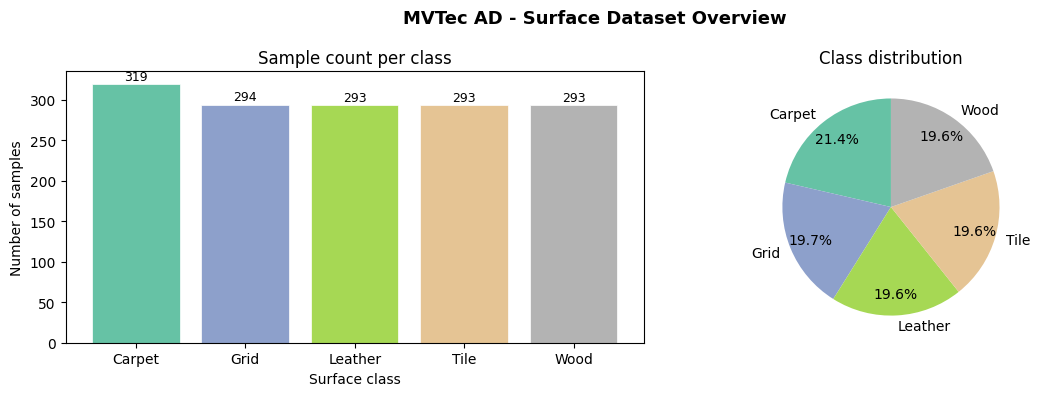

In [8]:
def compute_dataset_statistics(samples: list, surface_classes: list) -> pd.DataFrame:
    """
    Computes summary statistics per class from the sample list.
    Includes count, percentage, and sample image size.
    """
    class_to_idx = {cls: i for i, cls in enumerate(surface_classes)}
    stats = []

    for cls in surface_classes:
        idx     = class_to_idx[cls]
        paths   = [p for p, l in samples if l == idx]
        count   = len(paths)
        pct     = 100.0 * count / len(samples) if samples else 0

        widths, heights = [], []
        sample_n = min(20, count)
        for p in random.sample(paths, sample_n):
            try:
                with Image.open(p) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
            except Exception:
                pass

        stats.append({
            'Class':       cls.capitalize(),
            'Count':       count,
            'Percentage':  round(pct, 2),
            'Avg Width':   int(np.mean(widths))  if widths  else 0,
            'Avg Height':  int(np.mean(heights)) if heights else 0,
        })

    df = pd.DataFrame(stats)
    totals = pd.DataFrame([{
        'Class': 'TOTAL',
        'Count': df['Count'].sum(),
        'Percentage': 100.0,
        'Avg Width':  int(df['Avg Width'].mean()),
        'Avg Height': int(df['Avg Height'].mean())
    }])
    return pd.concat([df, totals], ignore_index=True)


stats_df = compute_dataset_statistics(all_samples, SURFACE_CLASSES)
print('\n--- Dataset Summary Statistics ---')
print(stats_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cls_names  = stats_df[stats_df['Class'] != 'TOTAL']['Class'].tolist()
cls_counts = stats_df[stats_df['Class'] != 'TOTAL']['Count'].tolist()
colors     = plt.cm.Set2(np.linspace(0, 1, len(cls_names)))

axes[0].bar(cls_names, cls_counts, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Sample count per class')
axes[0].set_xlabel('Surface class')
axes[0].set_ylabel('Number of samples')
for i, v in enumerate(cls_counts):
    axes[0].text(i, v + 2, str(v), ha='center', va='bottom', fontsize=9)

axes[1].pie(cls_counts, labels=cls_names, colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.8)
axes[1].set_title('Class distribution')

plt.suptitle('MVTec AD - Surface Dataset Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dataset_statistics.png'), dpi=150, bbox_inches='tight')
plt.show()

# Section 5 - Augmentation Transforms

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_train_transforms(img_size: int = 224, full_rotation: bool = False) -> T.Compose:
    rotation = T.RandomRotation(360) if full_rotation else T.RandomRotation(15)

    return T.Compose([
        T.Resize((img_size + 20, img_size + 20)),
        T.RandomCrop(img_size),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.3),
        rotation,
        T.ColorJitter(
            brightness=0.05,   # very slight brightness only
            contrast=0.0,
            saturation=0.0,
            hue=0.0
        ),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])


def get_val_transforms(img_size: int = 224) -> T.Compose:
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])


TRAIN_TRANSFORMS = get_train_transforms(IMG_SIZE, full_rotation=False)
VAL_TRANSFORMS   = get_val_transforms(IMG_SIZE)

print('Train transforms:', TRAIN_TRANSFORMS)
print('\nVal transforms:',  VAL_TRANSFORMS)

Train transforms: Compose(
    Resize(size=(244, 244), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.3)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.95, 1.05), contrast=None, saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


# Section 6 - Dataset and DataLoader Classes

In [10]:
class SurfaceDataset(Dataset):
    def __init__(self, samples: list, transform=None, classes: list = None):
        self.samples   = samples
        self.transform = transform
        self.classes   = classes or SURFACE_CLASSES

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        path, label = self.samples[idx]
        try:
            image = Image.open(path).convert('RGB')
        except Exception as e:
            print(f'Error loading {path}: {e}')
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=128)
        if self.transform:
            image = self.transform(image)
        return image, label

    def get_class_weights(self) -> torch.Tensor:
        counts = np.zeros(len(self.classes))
        for _, lbl in self.samples:
            counts[lbl] += 1
        weights = 1.0 / (counts + 1e-6)
        weights = weights / weights.sum() * len(self.classes)
        return torch.tensor(weights, dtype=torch.float32)


def split_samples(samples: list, val_split: float = 0.15,
                  test_split: float = 0.15, seed: int = 42,
                  train_only_paths: set = None) -> tuple:
    from sklearn.model_selection import train_test_split

    train_only_paths = train_only_paths or set()

    locked_train = [(p, l) for p, l in samples
                    if os.path.realpath(p) in train_only_paths]
    splittable   = [(p, l) for p, l in samples
                    if os.path.realpath(p) not in train_only_paths]

    paths  = [p for p, _ in splittable]
    labels = [l for _, l in splittable]

    paths_tv, paths_test, labels_tv, labels_test = train_test_split(
        paths, labels,
        test_size=test_split,
        stratify=labels,
        random_state=seed
    )

    val_fraction = val_split / (1.0 - test_split)
    paths_train, paths_val, labels_train, labels_val = train_test_split(
        paths_tv, labels_tv,
        test_size=val_fraction,
        stratify=labels_tv,
        random_state=seed
    )

    train_samples = list(zip(paths_train, labels_train)) + locked_train

    print(f'Locked train-only (defect + equalizer copies): {len(locked_train)}')
    print(f'Splittable pool — train: {len(paths_train)} | val: {len(paths_val)} | test: {len(paths_test)}')

    return (
        train_samples,
        list(zip(paths_val,   labels_val)),
        list(zip(paths_test,  labels_test))
    )


def build_dataloaders(train_samples, val_samples, test_samples,
                      batch_size: int = 32, num_workers: int = 2) -> tuple:
    train_ds = SurfaceDataset(train_samples, transform=TRAIN_TRANSFORMS)
    val_ds   = SurfaceDataset(val_samples,   transform=VAL_TRANSFORMS)
    test_ds  = SurfaceDataset(test_samples,  transform=VAL_TRANSFORMS)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
    return train_loader, val_loader, test_loader


train_samples, val_samples, test_samples = split_samples(
    all_samples, VAL_SPLIT, TEST_SPLIT,
    train_only_paths=train_only_paths
)

train_loader, val_loader, test_loader = build_dataloaders(
    train_samples, val_samples, test_samples, BATCH_SIZE, NUM_WORKERS
)

Locked train-only (defect + equalizer copies): 261
Splittable pool — train: 861 | val: 185 | test: 185
Train: 1122 | Val: 185 | Test: 185


# Section 7 - Model Architecture Classes

In [11]:
class EfficientNetB0Classifier(nn.Module):
    """
    EfficientNet-B0 fine-tuned for surface classification.
    Base layers frozen initially; full fine-tuning after warm-up.
    """

    def __init__(self, num_classes: int, dropout: float = 0.3,
                 freeze_base: bool = True):
        super().__init__()
        self.base = timm.create_model('efficientnet_b0', pretrained=True,
                                      num_classes=0, global_pool='avg')
        in_features = self.base.num_features

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout / 2),
            nn.Linear(256, num_classes)
        )

        if freeze_base:
            for param in self.base.parameters():
                param.requires_grad = False

    def unfreeze_base(self):
        """Unfreeze all backbone parameters for full fine-tuning."""
        for param in self.base.parameters():
            param.requires_grad = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.base(x)
        return self.classifier(features)


class MobileNetV3SmallClassifier(nn.Module):
    """
    MobileNetV3-Small fine-tuned for surface classification.
    """

    def __init__(self, num_classes: int, dropout: float = 0.2,
                 freeze_base: bool = True):
        super().__init__()
        base = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )

        self.features = base.features
        self.avgpool = base.avgpool
        in_features = base.classifier[0].in_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.Hardswish(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(256, num_classes)
        )

        if freeze_base:
            for param in self.features.parameters():
                param.requires_grad = False

    def unfreeze_base(self):
        for param in self.features.parameters():
            param.requires_grad = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def count_parameters(model: nn.Module) -> dict:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {'total': total, 'trainable': trainable,
            'frozen': total - trainable}

# Section 8 - Trainer Class

In [12]:
class EarlyStopping:
    """Stops training when val loss does not improve for 'patience' epochs."""

    def __init__(self, patience: int = 8, min_delta: float = 1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = float('inf')
        self.stop      = False

    def step(self, val_loss: float) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        return self.stop


class Trainer:
    """
    General-purpose trainer for PyTorch classification models.
    Handles:
    - Training and validation loops
    - Best checkpoint saving
    - LR scheduling (ReduceLROnPlateau)
    - Early stopping
    - Optional backbone unfreeze at a specified epoch
    """

    def __init__(self,
                 model: nn.Module,
                 train_loader: DataLoader,
                 val_loader: DataLoader,
                 optimizer: optim.Optimizer,
                 scheduler,
                 criterion: nn.Module,
                 model_name: str,
                 checkpoint_dir: str,
                 num_epochs: int = 15,
                 unfreeze_epoch: int = 5,
                 device: torch.device = DEVICE):

        self.model           = model
        self.train_loader    = train_loader
        self.val_loader      = val_loader
        self.optimizer       = optimizer
        self.scheduler       = scheduler
        self.criterion       = criterion
        self.model_name      = model_name
        self.checkpoint_path = os.path.join(checkpoint_dir, f'{model_name}_best.pt')
        self.num_epochs      = num_epochs
        self.unfreeze_epoch  = unfreeze_epoch
        self.device          = device
        self.early_stopping  = EarlyStopping(patience=EARLY_STOP_PATIENCE)

        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc':  [], 'val_acc':  [],
            'lr':         []
        }
        self.best_val_acc  = 0.0          # CHANGE 1 - added best_val_loss
        self.best_val_loss = float('inf')

    def _run_epoch(self, loader: DataLoader, training: bool) -> tuple:
        self.model.train() if training else self.model.eval()
        total_loss, correct, total = 0.0, 0, 0

        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for images, labels in loader:
                images = images.to(self.device, non_blocking=True)
                labels = labels.to(self.device, non_blocking=True)

                outputs = self.model(images)
                # BCEWithLogitsLoss expects float targets of same shape as outputs
                labels_onehot = torch.zeros_like(outputs).scatter_(
                    1, labels.unsqueeze(1), 1.0
                )
                loss = self.criterion(outputs, labels_onehot)

                if training:
                    self.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    self.optimizer.step()

                total_loss += loss.item() * images.size(0)
                # Use sigmoid (not softmax) for independent per-class probabilities
                probs  = torch.sigmoid(outputs)
                preds  = probs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total   += images.size(0)

        return total_loss / total, correct / total

    def train(self) -> dict:
        print(f'\nTraining: {self.model_name}')
        print('-' * 55)

        for epoch in range(1, self.num_epochs + 1):
            if epoch == self.unfreeze_epoch:
                if hasattr(self.model, 'unfreeze_base'):
                    self.model.unfreeze_base()
                    for pg in self.optimizer.param_groups:
                        pg['lr'] = pg['lr'] * 0.1
                    print(f'  Epoch {epoch}: backbone unfrozen, LR reduced x0.1')

            t_loss, t_acc = self._run_epoch(self.train_loader, training=True)
            v_loss, v_acc = self._run_epoch(self.val_loader,   training=False)

            self.scheduler.step(v_loss)
            current_lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['train_acc'].append(t_acc)
            self.history['val_acc'].append(v_acc)
            self.history['lr'].append(current_lr)

            # CHANGE 2 - save on better acc OR same acc with lower loss
            better_acc          = v_acc > self.best_val_acc
            same_acc_lower_loss = (v_acc == self.best_val_acc) and (v_loss < self.best_val_loss)

            if better_acc or same_acc_lower_loss:
                self.best_val_acc  = v_acc
                self.best_val_loss = v_loss
                torch.save({
                    'epoch':      epoch,
                    'model_name': self.model_name,
                    'state_dict': self.model.state_dict(),
                    'val_acc':    v_acc,
                    'val_loss':   v_loss,
                    'optimizer':  self.optimizer.state_dict()
                }, self.checkpoint_path)
                print(f'  Checkpoint saved - val_acc: {v_acc:.4f} val_loss: {v_loss:.4f}')

            print(f'  Ep {epoch:02d}/{self.num_epochs} | '
                  f'T-loss: {t_loss:.4f} T-acc: {t_acc:.4f} | '
                  f'V-loss: {v_loss:.4f} V-acc: {v_acc:.4f} | '
                  f'LR: {current_lr:.2e}')

            if self.early_stopping.step(v_loss):
                print(f'  Early stop at epoch {epoch}')
                break

        print(f'  Best val acc: {self.best_val_acc:.4f}')
        print(f'  Best val loss: {self.best_val_loss:.4f}')
        print(f'  Checkpoint: {self.checkpoint_path}')
        return self.history

    def load_best(self):
        """Load the best saved checkpoint into the model."""
        ckpt = torch.load(self.checkpoint_path, map_location=self.device)
        self.model.load_state_dict(ckpt['state_dict'])
        print(f'Loaded best checkpoint (epoch {ckpt["epoch"]}, '
              f'val_acc={ckpt["val_acc"]:.4f}, val_loss={ckpt["val_loss"]:.4f})')
        return self.model

print('Trainer class ready.')

Trainer class ready.


# Section 9 - Train EfficientNet-B0

In [ ]:
num_classes = len(SURFACE_CLASSES)

effnet_model = EfficientNetB0Classifier(
    num_classes=num_classes, dropout=0.3, freeze_base=True
).to(DEVICE)

effnet_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, effnet_model.parameters()),
    lr=1.e-3, weight_decay=1.e-4
)

effnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    effnet_optimizer, mode='min', factor=0.5,
    patience=SCHEDULER_PATIENCE
)

# BCEWithLogitsLoss: numerically stable sigmoid + BCE in one step.
# For multi-class (mutually exclusive) classification this gives sharper,
# per-class calibrated outputs compared to softmax + CrossEntropy,
# and makes the confidence threshold easier to interpret per-class.
# pos_weight applies class balancing (analogous to CrossEntropy weight).
_class_weights = SurfaceDataset(train_samples).get_class_weights().to(DEVICE)
effnet_criterion = nn.BCEWithLogitsLoss(pos_weight=_class_weights)

effnet_trainer = Trainer(
    model=effnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=effnet_optimizer,
    scheduler=effnet_scheduler,
    criterion=effnet_criterion,
    model_name='efficientnet_b0',
    checkpoint_dir=CHECKPOINT_DIR,
    num_epochs=30,
    unfreeze_epoch=8
)

effnet_history = effnet_trainer.train()
effnet_model   = effnet_trainer.load_best()

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


Training: efficientnet_b0
-------------------------------------------------------
  Checkpoint saved - val_acc: 1.0000 val_loss: 0.0740
  Ep 01/30 | T-loss: 0.1567 T-acc: 0.9545 | V-loss: 0.0740 V-acc: 1.0000 | LR: 1.00e-03
  Checkpoint saved - val_acc: 1.0000 val_loss: 0.0506
  Ep 02/30 | T-loss: 0.0161 T-acc: 0.9955 | V-loss: 0.0506 V-acc: 1.0000 | LR: 1.00e-03
  Checkpoint saved - val_acc: 1.0000 val_loss: 0.0235
  Ep 03/30 | T-loss: 0.0077 T-acc: 0.9982 | V-loss: 0.0235 V-acc: 1.0000 | LR: 1.00e-03
  Ep 04/30 | T-loss: 0.0073 T-acc: 0.9955 | V-loss: 0.0279 V-acc: 1.0000 | LR: 1.00e-03
  Checkpoint saved - val_acc: 1.0000 val_loss: 0.0172
  Ep 05/30 | T-loss: 0.0052 T-acc: 0.9991 | V-loss: 0.0172 V-acc: 1.0000 | LR: 1.00e-03
  Ep 06/30 | T-loss: 0.0077 T-acc: 0.9964 | V-loss: 0.0221 V-acc: 1.0000 | LR: 1.00e-03
  Checkpoint saved - val_acc: 1.0000 val_loss: 0.0060
  Ep 07/30 | T-loss: 0.0066 T-acc: 0.9991 | V-loss: 0.0060 V-acc: 1.0000 | LR: 1.00e-03
  Epoch 8: backbone unfrozen, L

# Section 10 - Train MobileNetV3-Small

In [ ]:
mobilenet_model = MobileNetV3SmallClassifier(
    num_classes=num_classes, dropout=0.2, freeze_base=True
).to(DEVICE)

mobilenet_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, mobilenet_model.parameters()),
    lr=1e-3, weight_decay=1e-3
)

mobilenet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    mobilenet_optimizer, mode='min', factor=0.5,
    patience=SCHEDULER_PATIENCE
)

_class_weights = SurfaceDataset(train_samples).get_class_weights().to(DEVICE)
mobilenet_criterion = nn.BCEWithLogitsLoss(pos_weight=_class_weights)

mobilenet_trainer = Trainer(
    model=mobilenet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=mobilenet_optimizer,
    scheduler=mobilenet_scheduler,
    criterion=mobilenet_criterion,
    model_name='mobilenet_v3_small',
    checkpoint_dir=CHECKPOINT_DIR,
    num_epochs=25,
    unfreeze_epoch=5
)

mobilenet_history = mobilenet_trainer.train()
mobilenet_model   = mobilenet_trainer.load_best()

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 123MB/s]


Training: mobilenet_v3_small
-------------------------------------------------------


  Checkpoint saved - val_acc: 0.8811 val_loss: 0.4670
  Ep 01/25 | T-loss: 0.1583 T-acc: 0.9519 | V-loss: 0.4670 V-acc: 0.8811 | LR: 1.00e-03
  Checkpoint saved - val_acc: 0.9838 val_loss: 0.3049
  Ep 02/25 | T-loss: 0.0149 T-acc: 0.9973 | V-loss: 0.3049 V-acc: 0.9838 | LR: 1.00e-03
  Checkpoint saved - val_acc: 0.9892 val_loss: 0.1549
  Ep 03/25 | T-loss: 0.0079 T-acc: 0.9991 | V-loss: 0.1549 V-acc: 0.9892 | LR: 1.00e-03
  Checkpoint saved - val_acc: 1.0000 val_loss: 0.0712
  Ep 04/25 | T-loss: 0.0049 T-acc: 0.9991 | V-loss: 0.0712 V-acc: 1.0000 | LR: 1.00e-03
  Epoch 5: backbone unfrozen, LR reduced x0.1
  Checkpoint saved - val_acc: 1.0000 val_loss: 0.0356
  Ep 05/25 | T-loss: 0.0037 T-acc: 0.9991 | V-loss: 0.0356 V-acc: 1.0000 | LR: 1.00e-04
  Checkpoint saved - val_acc: 1.0000 val_loss: 0.0194
  Ep 06/25 | T-loss: 0.0049 T-acc: 0.9991 | V-loss: 0.0194 V-acc: 1.0000 | LR: 1.00e-04
  Checkpoint saved - val_acc: 1.0000 val_loss: 0.0135
  Ep 07/25 | T-loss: 0.0034 T-acc: 0.9982 | V-lo

# Section 11 - Train YOLO11n-cls

## Build YOLO Classification Dataset

Copies images into the folder structure required by YOLO classification training: `split/class_name/image`.

In [ ]:
# YOLO classification requires images arranged as:
# yolo_dataset/
#   train/<class_name>/*.jpg
#   val/<class_name>/*.jpg
#   test/<class_name>/*.jpg

import shutil

YOLO_DIR = os.path.join(ROOT_PATH, 'yolo_cls_dataset')

def build_yolo_cls_dataset(train_s, val_s, test_s,
                            classes: list, yolo_dir: str):
    """
    Creates symlink-free YOLO classification folder structure
    by copying images into the required layout.
    """
    for split_name, split_data in [('train', train_s),
                                    ('val',   val_s),
                                    ('test',  test_s)]:
        for cls in classes:
            os.makedirs(os.path.join(yolo_dir, split_name, cls), exist_ok=True)

        for path, lbl in tqdm(split_data, desc=f'Building YOLO {split_name}'):
            cls_name = classes[lbl]
            dst_dir  = os.path.join(yolo_dir, split_name, cls_name)
            dst_path = os.path.join(dst_dir, os.path.basename(path))
            if not os.path.exists(dst_path):
                shutil.copy2(path, dst_path)

    print(f'YOLO dataset ready at: {yolo_dir}')


build_yolo_cls_dataset(
    train_samples, val_samples, test_samples,
    SURFACE_CLASSES, YOLO_DIR
)

Building YOLO test: 100%|██████████| 185/185 [00:00<00:00, 1308.09it/s]

YOLO dataset ready at: /content/data/yolo_cls_dataset


## Train YOLO11n-cls

In [ ]:
YOLO_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'yolo11n_cls')

yolo_model = YOLO('yolo11n-cls.pt')

yolo_results = yolo_model.train(
    data=YOLO_DIR,
    epochs=NUM_EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    lr0=YOLO_LR,
    lrf=0.01,
    weight_decay=WEIGHT_DECAY,
    warmup_epochs=3,
    optimizer='AdamW',
    augment=True,
    hsv_h=0.015,
    hsv_s=0.3,
    hsv_v=0.2,
    flipud=0.3,
    fliplr=0.5,
    degrees=15,
    project=CHECKPOINT_DIR,
    name='yolo11n_cls',
    exist_ok=True,
    patience=EARLY_STOP_PATIENCE,
    verbose=True
)

YOLO_BEST_PT = os.path.join(CHECKPOINT_DIR, 'yolo11n_cls', 'weights', 'best.pt')
yolo_model   = YOLO(YOLO_BEST_PT)


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/yolo_cls_dataset, degrees=15, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.2, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_cls, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=13, p

# Section 12 - Inference Utilities with Unknown Class

## Load EfficientNet-B0 Checkpoint

In [13]:
num_classes  = len(SURFACE_CLASSES)
effnet_model = EfficientNetB0Classifier(
    num_classes=num_classes, dropout=0.3, freeze_base=True
).to(DEVICE)

ckpt = torch.load(os.path.join(CHECKPOINT_DIR, 'efficientnet_b0_best.pt'), map_location=DEVICE)
effnet_model.load_state_dict(ckpt['state_dict'])
effnet_model.eval()
print(f'EfficientNet loaded: epoch {ckpt["epoch"]}  val_acc={ckpt["val_acc"]:.4f}')

with open(os.path.join(RESULTS_DIR, 'EfficientNet-B0_history.json')) as f:
    effnet_history = json.load(f)
print('EfficientNet history loaded.')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet loaded: epoch 7  val_acc=1.0000
EfficientNet history loaded.


## Load MobileNetV3-Small Checkpoint

In [14]:
mobilenet_model = MobileNetV3SmallClassifier(
    num_classes=num_classes, dropout=0.2, freeze_base=True
).to(DEVICE)

ckpt = torch.load(os.path.join(CHECKPOINT_DIR, 'mobilenet_v3_small_best.pt'), map_location=DEVICE)
mobilenet_model.load_state_dict(ckpt['state_dict'])
mobilenet_model.eval()
print(f'MobileNet loaded: epoch {ckpt["epoch"]}  val_acc={ckpt["val_acc"]:.4f}')

with open(os.path.join(RESULTS_DIR, 'MobileNetV3-Small_history.json')) as f:
    mobilenet_history = json.load(f)
print('MobileNet history loaded.')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 96.6MB/s]


MobileNet loaded: epoch 24  val_acc=1.0000
MobileNet history loaded.


## Load YOLO Checkpoint

In [15]:
YOLO_BEST_PT = os.path.join(CHECKPOINT_DIR, 'yolo11n_cls', 'weights', 'best.pt')
yolo_model   = YOLO(YOLO_BEST_PT)
print(f'YOLO loaded from {YOLO_BEST_PT}')

with open(os.path.join(RESULTS_DIR, 'YOLO11n-cls_history.json')) as f:
    yolo_history = json.load(f)
print('YOLO history loaded.')

YOLO loaded from /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/checkpoints/yolo11n_cls/weights/best.pt
YOLO history loaded.


## Run Inference on Test Set

Runs all three models over the test set and collects predicted labels, probabilities, and ground-truth labels.

In [ ]:
def predict_pytorch(model: nn.Module, loader: DataLoader,
                    threshold: float = CONFIDENCE_THRESHOLD,
                    device: torch.device = DEVICE) -> tuple:
    """
    Runs inference with a PyTorch model.
    Predictions below 'threshold' confidence are assigned UNKNOWN (-1).
    Returns (all_probs, predicted_labels, true_labels).
    """
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            logits = model(images)
            # sigmoid gives independent per-class probabilities (sums != 1)
            # which is consistent with BCEWithLogitsLoss training
            probs  = torch.sigmoid(logits).cpu()

            max_probs, preds = probs.max(dim=1)
            for i in range(len(preds)):
                if max_probs[i].item() < threshold:
                    all_preds.append(-1)
                else:
                    all_preds.append(preds[i].item())

            all_probs.append(probs.numpy())
            all_labels.extend(labels.tolist())

    all_probs = np.concatenate(all_probs, axis=0)
    return all_probs, np.array(all_preds), np.array(all_labels)


def predict_yolo(yolo_model, loader: DataLoader,
                 threshold: float = CONFIDENCE_THRESHOLD) -> tuple:
    """
    Runs inference with YOLO classification model.
    Returns (all_probs, predicted_labels, true_labels).
    """
    all_probs, all_preds, all_labels = [], [], []

    for images, labels in tqdm(loader, desc='YOLO inference'):
        for i in range(images.size(0)):
            img_np = images[i].permute(1, 2, 0).numpy()
            img_np = ((img_np * np.array(IMAGENET_STD) +
                       np.array(IMAGENET_MEAN)) * 255).clip(0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np)

            result = yolo_model(pil_img, verbose=False)[0]
            probs  = result.probs.data.cpu().numpy().flatten()

            if len(probs) != len(SURFACE_CLASSES):
                probs = np.ones(len(SURFACE_CLASSES)) / len(SURFACE_CLASSES)

            pred = int(probs.argmax())
            conf = float(probs.max())

            all_probs.append(probs)
            all_preds.append(pred if conf >= threshold else -1)

        all_labels.extend(labels.tolist())

    all_probs  = np.stack(all_probs, axis=0)
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    print(f'YOLO probs shape: {all_probs.shape}')
    print(f'YOLO conf range: {all_probs.max(axis=1).min():.3f} - {all_probs.max(axis=1).max():.3f}')

    return all_probs, all_preds, all_labels


print('Running inference on test set...')
effnet_probs,    effnet_preds,    effnet_labels    = predict_pytorch(effnet_model,    test_loader)
mobilenet_probs, mobilenet_preds, mobilenet_labels = predict_pytorch(mobilenet_model, test_loader)
yolo_probs,      yolo_preds,      yolo_labels      = predict_yolo(yolo_model,         test_loader)
print('Inference complete.')

Running inference on test set...


YOLO inference: 100%|██████████| 6/6 [00:04<00:00,  1.33it/s]

YOLO probs shape: (185, 5)
YOLO conf range: 1.000 - 1.000
Inference complete.


# Section 13 - Evaluation Metrics

## Load Best Checkpoints and Training Histories

In [ ]:
num_classes = len(SURFACE_CLASSES)

effnet_model    = EfficientNetB0Classifier(num_classes=num_classes, dropout=0.3, freeze_base=True).to(DEVICE)
mobilenet_model = MobileNetV3SmallClassifier(num_classes=num_classes, dropout=0.2, freeze_base=True).to(DEVICE)

YOLO_BEST_PT = os.path.join(CHECKPOINT_DIR, 'yolo11n_cls', 'weights', 'best.pt')


def load_checkpoint(model: nn.Module, model_name: str,
                    checkpoint_dir: str, device: torch.device = DEVICE) -> nn.Module:
    ckpt_path = os.path.join(checkpoint_dir, f'{model_name}_best.pt')
    if not os.path.exists(ckpt_path):
        print(f'  [WARN] No checkpoint found for {model_name} at {ckpt_path}')
        return model
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['state_dict'])
    print(f'  {model_name}: loaded epoch {ckpt["epoch"]}  '
          f'val_acc={ckpt["val_acc"]:.4f}  val_loss={ckpt["val_loss"]:.4f}')
    model.eval()
    return model


def load_training_histories(save_dir: str) -> dict:
    histories = {}
    for fname in sorted(os.listdir(save_dir)):
        if not fname.endswith('_history.json'):
            continue
        model_name = fname.replace('_history.json', '')
        path = os.path.join(save_dir, fname)
        with open(path, 'r') as f:
            histories[model_name] = json.load(f)
        print(f'  {model_name}: history loaded from {path}')
    return histories


print('Loading best checkpoints...')
effnet_model    = load_checkpoint(effnet_model,    'efficientnet_b0',    CHECKPOINT_DIR)
mobilenet_model = load_checkpoint(mobilenet_model, 'mobilenet_v3_small', CHECKPOINT_DIR)
yolo_model      = YOLO(YOLO_BEST_PT)
print('Checkpoints loaded.')

print('Loading training histories...')
all_histories = load_training_histories(RESULTS_DIR)
effnet_history    = all_histories.get('EfficientNet-B0',   {})
mobilenet_history = all_histories.get('MobileNetV3-Small', {})
yolo_history      = all_histories.get('YOLO11n-cls',       {})
print('Histories loaded.')


Loading best checkpoints...
  efficientnet_b0: loaded epoch 7  val_acc=1.0000  val_loss=0.0060
  mobilenet_v3_small: loaded epoch 24  val_acc=1.0000  val_loss=0.0037
Checkpoints loaded.
Loading training histories...
  EfficientNet-B0: history loaded from /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/EfficientNet-B0_history.json
  MobileNetV3-Small: history loaded from /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/MobileNetV3-Small_history.json
  YOLO11n-cls: history loaded from /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/YOLO11n-cls_history.json
Histories loaded.


## Compute Evaluation Metrics

Calculates accuracy, F1, precision, recall, ROC-AUC, Cohen Kappa, MCC, coverage, and per-class F1 for each model.

In [16]:
def draw_single_table(df: pd.DataFrame, title: str, save_path: str = None):
    """
    Reusable styled table function.
    Pass any DataFrame and a title — works for summary, timing, breakdown tables, etc.
    """
    header_color = '#2C3E6B'
    header_text  = 'white'
    row_color    = 'white'
    text_color   = '#1a1a1a'

    n_cols     = len(df.columns)
    n_rows     = len(df)
    fig_width  = n_cols * 2.2
    fig_height = n_rows * 0.45 + 1.2

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold',
                 color=header_color, pad=12, loc='left')

    tbl = ax.table(
        cellText=df.values.tolist(),
        colLabels=df.columns.tolist(),
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.6)

    for j in range(n_cols):
        cell = tbl[(0, j)]
        cell.set_facecolor(header_color)
        cell.set_text_props(color=header_text, fontweight='bold')
        cell.set_edgecolor('white')

    for i in range(1, n_rows + 1):
        for j in range(n_cols):
            cell = tbl[(i, j)]
            cell.set_facecolor(row_color)
            cell.set_edgecolor('#cccccc')
            fw = 'bold' if j == 0 else 'normal'
            cell.set_text_props(color=text_color, fontweight=fw)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    top_k_accuracy_score, cohen_kappa_score,
    matthews_corrcoef, confusion_matrix, classification_report
)

def compute_metrics(probs: np.ndarray, preds: np.ndarray,
                    labels: np.ndarray, class_names: list) -> dict:
    known_mask = preds != -1
    p_known    = preds[known_mask]
    l_known    = labels[known_mask]
    prob_known = probs[known_mask]
    n_unknown  = int((preds == -1).sum())
    coverage   = known_mask.mean()

    if len(p_known) == 0:
        print('  [WARN] No valid predictions to evaluate.')
        return {k: 0.0 for k in [
            'accuracy', 'top2_accuracy', 'f1_macro', 'f1_weighted',
            'precision_macro', 'recall_macro',
            'cohen_kappa', 'mcc', 'coverage', 'n_unknown'
        ]} | {'per_class_f1': {cls: 0.0 for cls in class_names},
               'n_unknown': n_unknown, 'coverage': float(coverage)}

    acc   = accuracy_score(l_known, p_known)
    top2  = top_k_accuracy_score(l_known, prob_known, k=min(2, len(class_names)),
                                 labels=list(range(len(class_names))))
    f1_mac = f1_score(l_known, p_known, average='macro', zero_division=0,
                      labels=list(range(len(class_names))))
    f1_wei = f1_score(l_known, p_known, average='weighted', zero_division=0,
                      labels=list(range(len(class_names))))
    prec   = precision_score(l_known, p_known, average='macro', zero_division=0,
                             labels=list(range(len(class_names))))
    rec    = recall_score(l_known, p_known, average='macro', zero_division=0,
                          labels=list(range(len(class_names))))
    kappa  = cohen_kappa_score(l_known, p_known,
                               labels=list(range(len(class_names))))
    mcc    = matthews_corrcoef(l_known, p_known)

    per_class_f1 = f1_score(l_known, p_known, average=None, zero_division=0,
                            labels=list(range(len(class_names))))
    per_class = {class_names[i]: round(float(per_class_f1[i]), 4)
                 for i in range(len(class_names))}

    return {
        'accuracy':        round(acc, 4),
        'top2_accuracy':   round(top2, 4),
        'f1_macro':        round(f1_mac, 4),
        'f1_weighted':     round(f1_wei, 4),
        'precision_macro': round(prec, 4),
        'recall_macro':    round(rec, 4),
        'cohen_kappa':     round(kappa, 4),
        'mcc':             round(mcc, 4),
        'coverage':        round(float(coverage), 4),
        'n_unknown':       n_unknown,
        'per_class_f1':    per_class
    }


effnet_metrics    = compute_metrics(effnet_probs,    effnet_preds,    effnet_labels,    SURFACE_CLASSES)
mobilenet_metrics = compute_metrics(mobilenet_probs, mobilenet_preds, mobilenet_labels, SURFACE_CLASSES)
yolo_metrics      = compute_metrics(yolo_probs,      yolo_preds,      yolo_labels,      SURFACE_CLASSES)

for name, m in [('EfficientNet-B0',   effnet_metrics),
                ('MobileNetV3-Small', mobilenet_metrics),
                ('YOLO11n-cls',       yolo_metrics)]:
    print(f'\n{name}')
    for k, v in m.items():
        if k != 'per_class_f1':
            print(f'  {k:20s}: {v}')


EfficientNet-B0
  accuracy            : 0.9946
  top2_accuracy       : 1.0
  f1_macro            : 0.9947
  f1_weighted         : 0.9946
  precision_macro     : 0.9944
  recall_macro        : 0.995
  cohen_kappa         : 0.9932
  mcc                 : 0.9933
  coverage            : 1.0
  n_unknown           : 0

MobileNetV3-Small
  accuracy            : 1.0
  top2_accuracy       : 1.0
  f1_macro            : 1.0
  f1_weighted         : 1.0
  precision_macro     : 1.0
  recall_macro        : 1.0
  cohen_kappa         : 1.0
  mcc                 : 1.0
  coverage            : 1.0
  n_unknown           : 0

YOLO11n-cls
  accuracy            : 1.0
  top2_accuracy       : 1.0
  f1_macro            : 1.0
  f1_weighted         : 1.0
  precision_macro     : 1.0
  recall_macro        : 1.0
  cohen_kappa         : 1.0
  mcc                 : 1.0
  coverage            : 1.0
  n_unknown           : 0


# Section 14 - Accuracy and Loss Curves

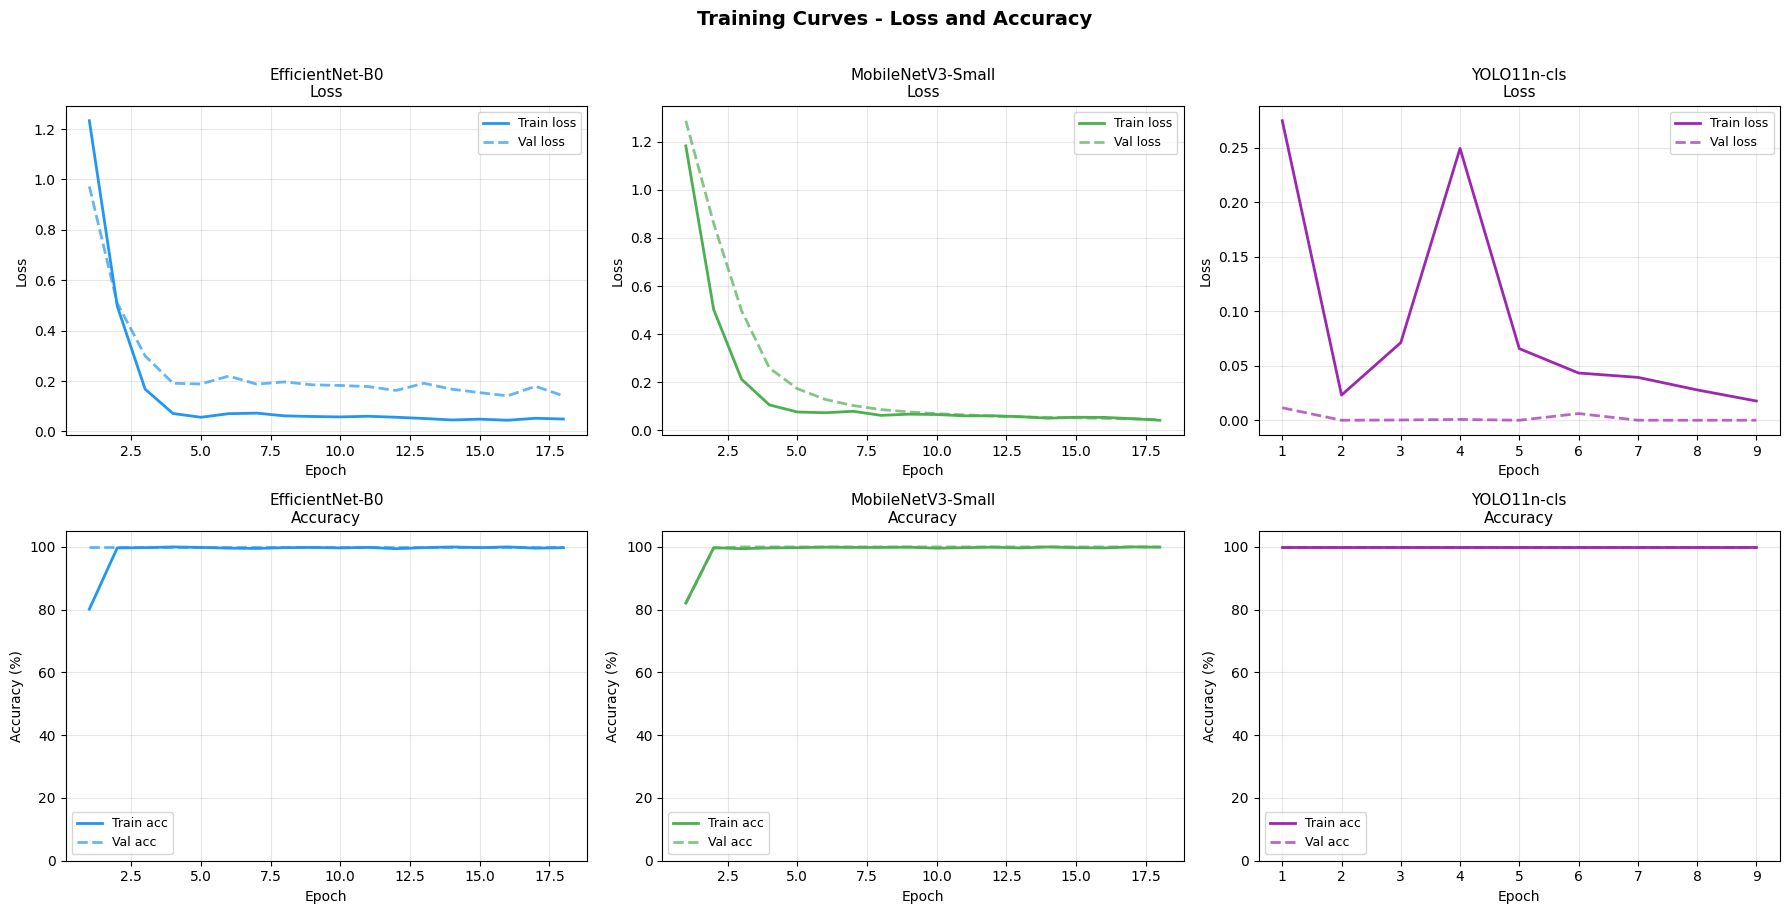

Curves saved: /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/training_curves.png


In [ ]:
def plot_training_curves(histories: dict, save_path: str):
    """
    Plots accuracy and loss curves for all models.
    Each model occupies one column, rows are loss and accuracy.
    """
    model_names = list(histories.keys())
    n_models    = len(model_names)
    palette     = ['#2196F3', '#4CAF50', '#9C27B0', '#FF5722', '#FFC107']

    fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 9))
    fig.suptitle('Training Curves - Loss and Accuracy', fontsize=14, fontweight='bold', y=1.01)

    if n_models == 1:
        axes = np.array(axes).reshape(2, 1)

    for col, (model_name, history) in enumerate(histories.items()):
        color  = palette[col % len(palette)]
        epochs = range(1, len(history.get('train_loss', [])) + 1)

        ax_loss = axes[0][col]
        ax_acc  = axes[1][col]

        if history.get('train_loss'):
            ax_loss.plot(epochs, history['train_loss'],
                         label='Train loss', color=color, linewidth=2)
            ax_loss.plot(epochs, history['val_loss'],
                         label='Val loss', color=color, linewidth=2,
                         linestyle='--', alpha=0.7)
        ax_loss.set_title(f'{model_name}\nLoss', fontsize=11)
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.legend(fontsize=9)
        ax_loss.grid(True, alpha=0.3)

        if history.get('train_acc'):
            ax_acc.plot(epochs, [a * 100 for a in history['train_acc']],
                        label='Train acc', color=color, linewidth=2)
            ax_acc.plot(epochs, [a * 100 for a in history['val_acc']],
                        label='Val acc', color=color, linewidth=2,
                        linestyle='--', alpha=0.7)
        ax_acc.set_title(f'{model_name}\nAccuracy', fontsize=11)
        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Accuracy (%)')
        ax_acc.set_ylim(0, 105)
        ax_acc.legend(fontsize=9)
        ax_acc.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Curves saved: {save_path}')


all_histories = {
    'EfficientNet-B0':   effnet_history,
    'MobileNetV3-Small': mobilenet_history,
    'YOLO11n-cls':       yolo_history
}

plot_training_curves(
    all_histories,
    save_path=os.path.join(RESULTS_DIR, 'training_curves.png')
)

# Section 15 - Confusion Matrices

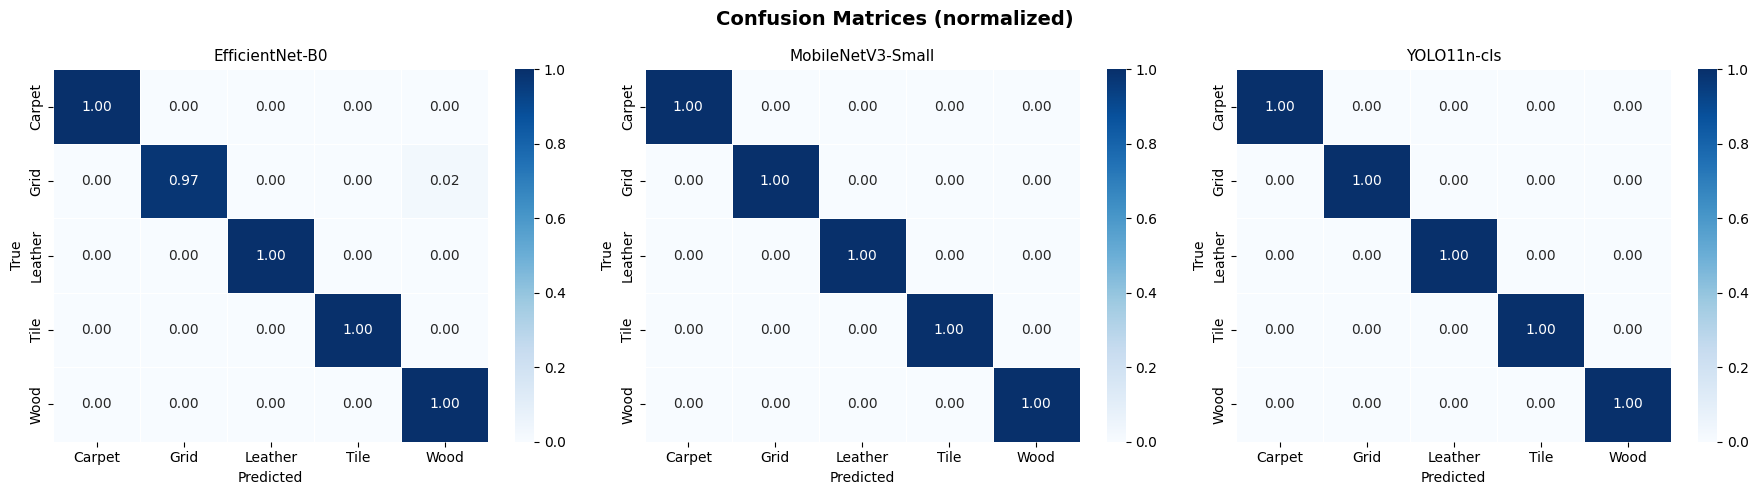

Confusion matrices saved: /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/confusion_matrices.png


In [ ]:
def plot_confusion_matrices(results: list, class_names: list, save_path: str):
    """
    Plots normalized confusion matrices for all models in one row.
    'results' is a list of (model_name, preds, labels) tuples.
    """
    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
    fig.suptitle('Confusion Matrices (normalized)', fontsize=14, fontweight='bold')

    if len(results) == 1:
        axes = [axes]

    for ax, (model_name, preds, labels) in zip(axes, results):
        known_mask = preds != -1
        p_k = preds[known_mask]
        l_k = labels[known_mask]

        cm  = confusion_matrix(l_k, p_k, labels=list(range(len(class_names))))
        cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

        sns.heatmap(
            cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[c.capitalize() for c in class_names],
            yticklabels=[c.capitalize() for c in class_names],
            ax=ax, linewidths=0.5, vmin=0, vmax=1
        )
        ax.set_title(model_name, fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Confusion matrices saved: {save_path}')


cm_results = [
    ('EfficientNet-B0',   effnet_preds,    effnet_labels),
    ('MobileNetV3-Small', mobilenet_preds, mobilenet_labels),
    ('YOLO11n-cls',       yolo_preds,      yolo_labels)
]

plot_confusion_matrices(
    cm_results, SURFACE_CLASSES,
    save_path=os.path.join(RESULTS_DIR, 'confusion_matrices.png')
)

# Section 16 - Confidence Score Distributions

## Plot Confidence Score Distributions

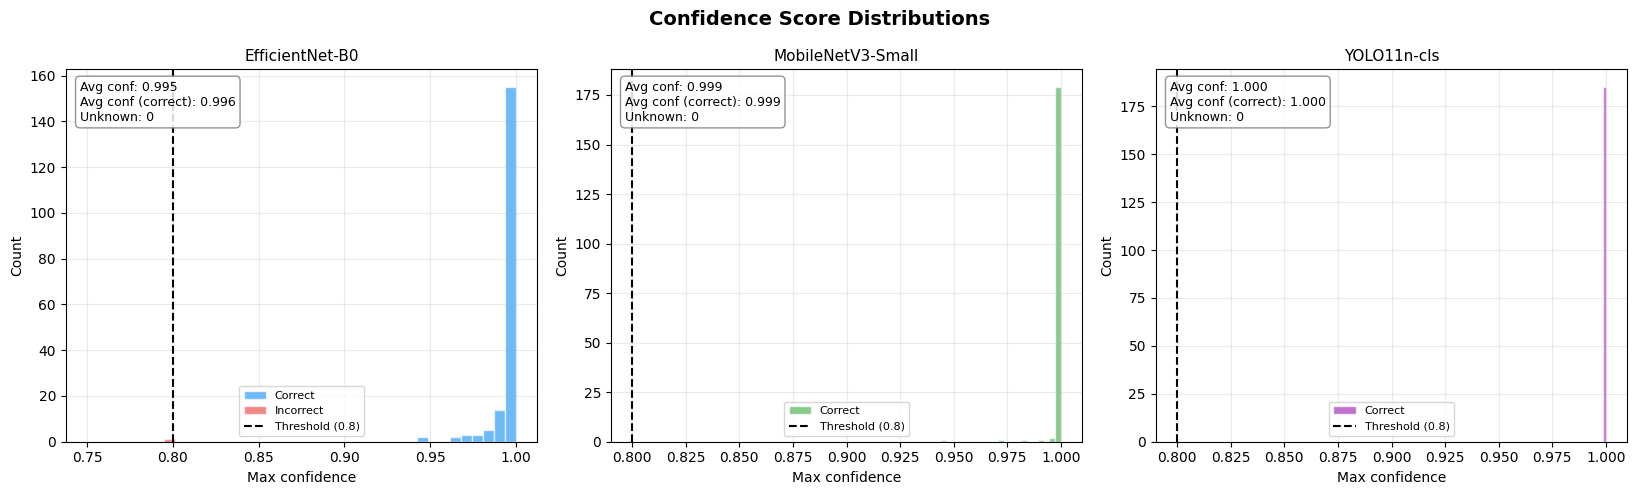

Confidence distributions saved: /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/confidence_distributions.png


In [ ]:
def plot_confidence_distributions(prob_results: list,
                                  threshold: float,
                                  save_path: str):
    palette = ['#2196F3', '#4CAF50', '#9C27B0', '#FF5722', '#FFC107']
    fig, axes = plt.subplots(1, len(prob_results),
                             figsize=(5.5 * len(prob_results), 5))
    fig.suptitle('Confidence Score Distributions', fontsize=14, fontweight='bold')

    if len(prob_results) == 1:
        axes = [axes]

    for ax, (model_name, probs, preds, labels), color in zip(
            axes, prob_results, palette):

        probs_arr = np.array(probs)
        max_confs = probs_arr.max(axis=1) if probs_arr.ndim > 1 else probs_arr

        correct   = (preds == labels) & (preds != -1)
        incorrect = (preds != labels) & (preds != -1)
        unknown   = preds == -1

        avg_conf         = max_confs.mean()
        avg_conf_correct = max_confs[correct].mean() if correct.any() else 0.0
        n_unknown        = int(unknown.sum())

        x_min = max(0.0, float(max_confs.min()) - 0.05)
        x_max = 1.0
        bins  = np.linspace(x_min, x_max, 40)

        if correct.any():
            ax.hist(max_confs[correct], bins=bins, alpha=0.65, label='Correct',
                    color=color, edgecolor='white')
        if incorrect.any():
            ax.hist(max_confs[incorrect], bins=bins, alpha=0.6, label='Incorrect',
                    color='#E53935', edgecolor='white')
        if unknown.any():
            ax.hist(max_confs[unknown], bins=bins, alpha=0.5, label='Unknown',
                    color='#9E9E9E', edgecolor='white')

        ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5,
                   label=f'Threshold ({threshold})')

        stats_text = (
            f'Avg conf: {avg_conf:.3f}\n'
            f'Avg conf (correct): {avg_conf_correct:.3f}\n'
            f'Unknown: {n_unknown}'
        )
        ax.text(0.03, 0.97, stats_text,
                transform=ax.transAxes,
                fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.35',
                          facecolor='white', alpha=0.85, edgecolor='gray'))

        ax.set_title(model_name, fontsize=11)
        ax.set_xlabel('Max confidence')
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Confidence distributions saved: {save_path}')


conf_results = [
    ('EfficientNet-B0',   effnet_probs,    effnet_preds,    effnet_labels),
    ('MobileNetV3-Small', mobilenet_probs, mobilenet_preds, mobilenet_labels),
    ('YOLO11n-cls',       yolo_probs,      yolo_preds,      yolo_labels)
]

plot_confidence_distributions(
    conf_results, CONFIDENCE_THRESHOLD,
    save_path=os.path.join(RESULTS_DIR, 'confidence_distributions.png')
)

## Inspect Unknown Predictions

In [ ]:
mobilenet_probs_arr = np.array(mobilenet_probs)
unknown_mask = mobilenet_preds == -1
unknown_indices = np.where(unknown_mask)[0]

for idx in unknown_indices:
    path, _ = test_samples[idx]
    conf = mobilenet_probs_arr[idx].max()
    pred = mobilenet_probs_arr[idx].argmax()
    print(f'{path}  conf={conf:.4f}  pred={SURFACE_CLASSES[pred]}  true={SURFACE_CLASSES[mobilenet_labels[idx]]}')

# Section 17 - Per-Class F1 Radar Chart

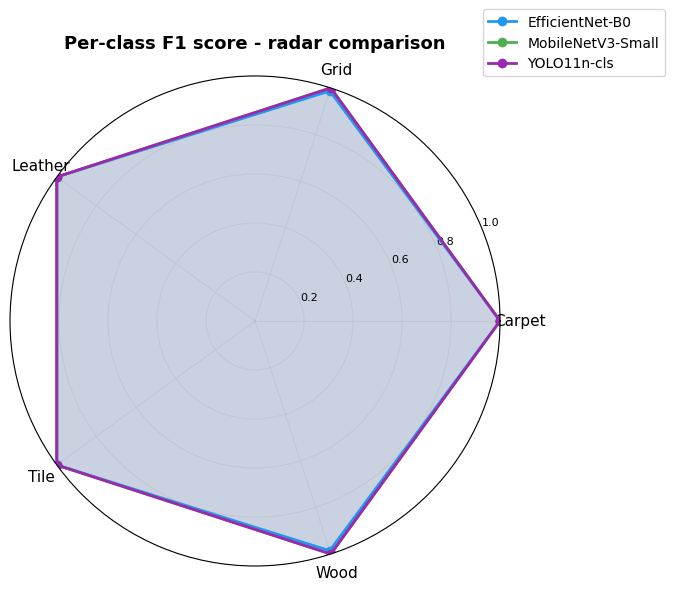

Radar chart saved: /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/per_class_f1_radar.png


In [ ]:
def plot_per_class_f1_radar(metrics_dict: dict, class_names: list, save_path: str):
    """
    Radar chart showing per-class F1 scores for all models.
    Allows quick comparison of which classes each model handles best.
    """
    N      = len(class_names)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    colors     = ['#2196F3', '#4CAF50', '#9C27B0', '#FF5722', '#FFC107']
    model_list = list(metrics_dict.items())

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for (model_name, metrics), color in zip(model_list, colors):
        values = [metrics['per_class_f1'].get(cls, 0) for cls in class_names]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, color=color, label=model_name)
        ax.fill(angles, values, alpha=0.12, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([c.capitalize() for c in class_names], size=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=8)
    ax.set_title('Per-class F1 score - radar comparison', fontsize=13,
                 fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Radar chart saved: {save_path}')


all_metrics = {
    'EfficientNet-B0':   effnet_metrics,
    'MobileNetV3-Small': mobilenet_metrics,
    'YOLO11n-cls':       yolo_metrics
}

plot_per_class_f1_radar(
    all_metrics, SURFACE_CLASSES,
    save_path=os.path.join(RESULTS_DIR, 'per_class_f1_radar.png')
)

Saved: /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/EfficientNet-B0_breakdown.png


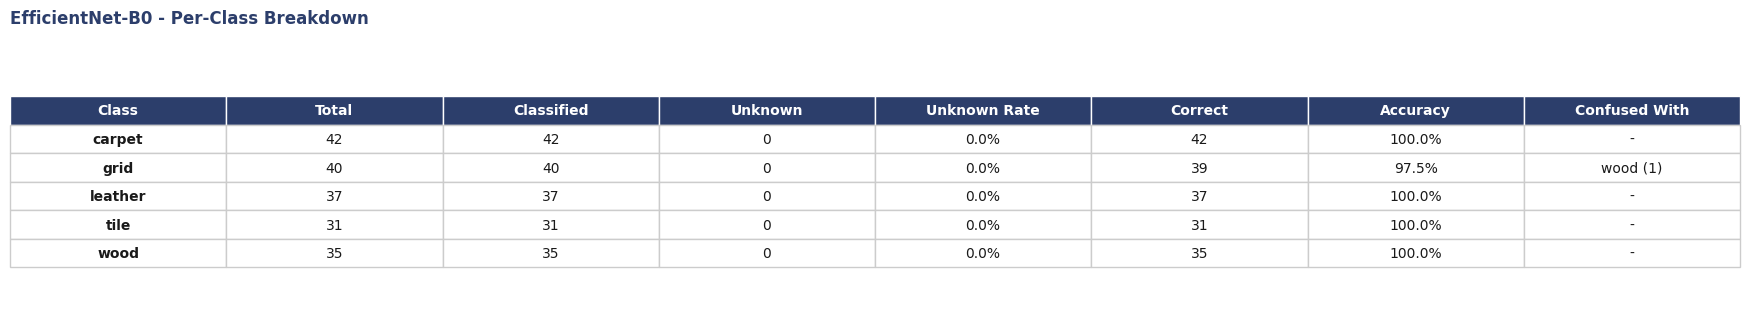

Saved: /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/MobileNetV3-Small_breakdown.png


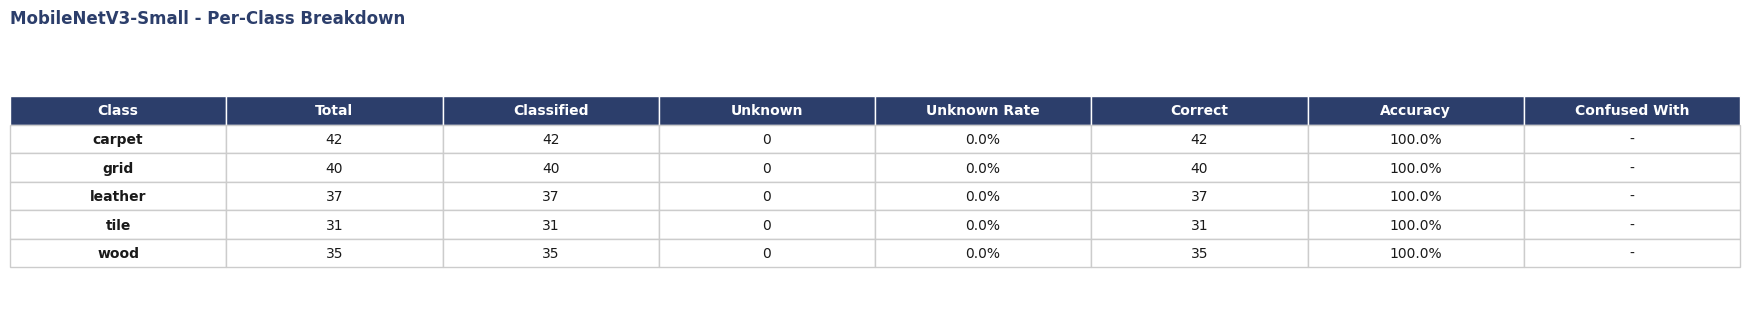

Saved: /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/YOLO11n-cls_breakdown.png


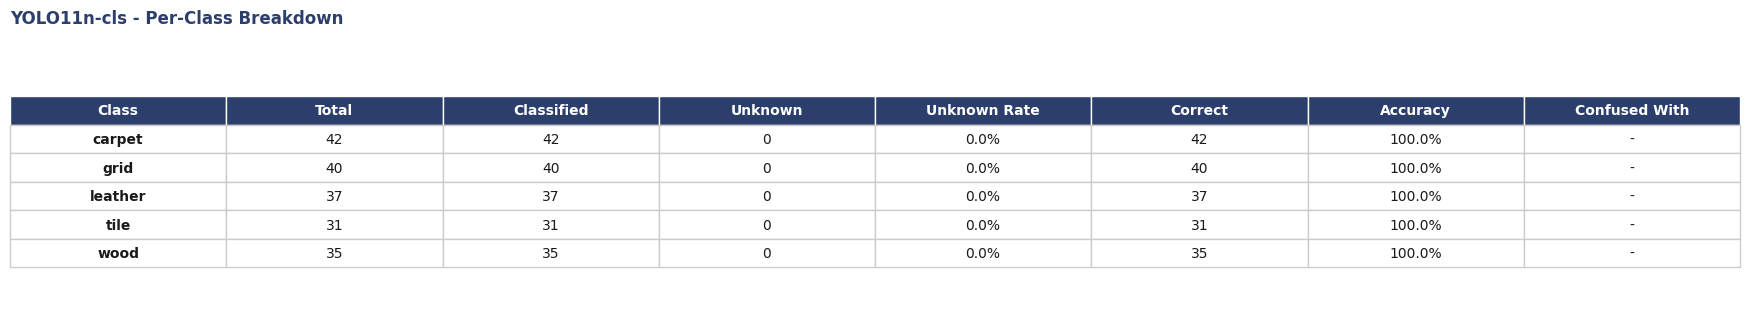

In [ ]:
from collections import Counter

def build_per_model_summary(probs, preds, labels, class_names):
    """One row per class with all metrics combined into a single table."""
    rows = []
    for i, cls in enumerate(class_names):
        class_mask   = labels == i
        known_mask   = preds != -1
        unknown_mask = preds == -1

        n_total      = int(class_mask.sum())
        n_unknown    = int((class_mask & unknown_mask).sum())
        n_known      = int((class_mask & known_mask).sum())
        correct      = int(((preds == i) & class_mask & known_mask).sum())
        accuracy     = correct / n_known   if n_known   > 0 else 0.0
        reject_rate  = n_unknown / n_total if n_total   > 0 else 0.0

        # Misclassifications
        wrong_mask  = class_mask & known_mask & (preds != i)
        wrong_preds = preds[wrong_mask]
        if len(wrong_preds) > 0:
            counts    = Counter(wrong_preds.tolist())
            confused  = ', '.join(
                f'{class_names[p]} ({c})' for p, c in counts.most_common()
            )
        else:
            confused = '-'

        rows.append({
            'Class':            cls,
            'Total':            n_total,
            'Classified':       n_known,
            'Unknown':          n_unknown,
            'Unknown Rate':     f'{reject_rate:.1%}',
            'Correct':          correct,
            'Accuracy':         f'{accuracy:.1%}',
            'Confused With':    confused,
        })

    return pd.DataFrame(rows)


# ── Run for all models ─────────────────────────────────────────
for model_name, probs, preds, labels in [
    ('EfficientNet-B0',   effnet_probs,    effnet_preds,    effnet_labels),
    ('MobileNetV3-Small', mobilenet_probs, mobilenet_preds, mobilenet_labels),
    ('YOLO11n-cls',       yolo_probs,      yolo_preds,      yolo_labels),
]:
    df = build_per_model_summary(probs, preds, labels, SURFACE_CLASSES)
    draw_single_table(
        df,
        title     = f'{model_name} - Per-Class Breakdown',
        save_path = os.path.join(RESULTS_DIR, f'{model_name.replace(" ", "_")}_breakdown.png')
    )

# Section 18 - Summary Metrics Table


--- Model Evaluation Summary ---
             Metric  EfficientNet-B0  MobileNetV3-Small  YOLO11n-cls
           Accuracy           0.9946                1.0          1.0
     Top-2 Accuracy           1.0000                1.0          1.0
         F1 (Macro)           0.9947                1.0          1.0
      F1 (Weighted)           0.9946                1.0          1.0
  Precision (Macro)           0.9944                1.0          1.0
     Recall (Macro)           0.9950                1.0          1.0
        Cohen Kappa           0.9932                1.0          1.0
                MCC           0.9933                1.0          1.0
           Coverage           1.0000                1.0          1.0
Unknown Predictions           0.0000                0.0          0.0


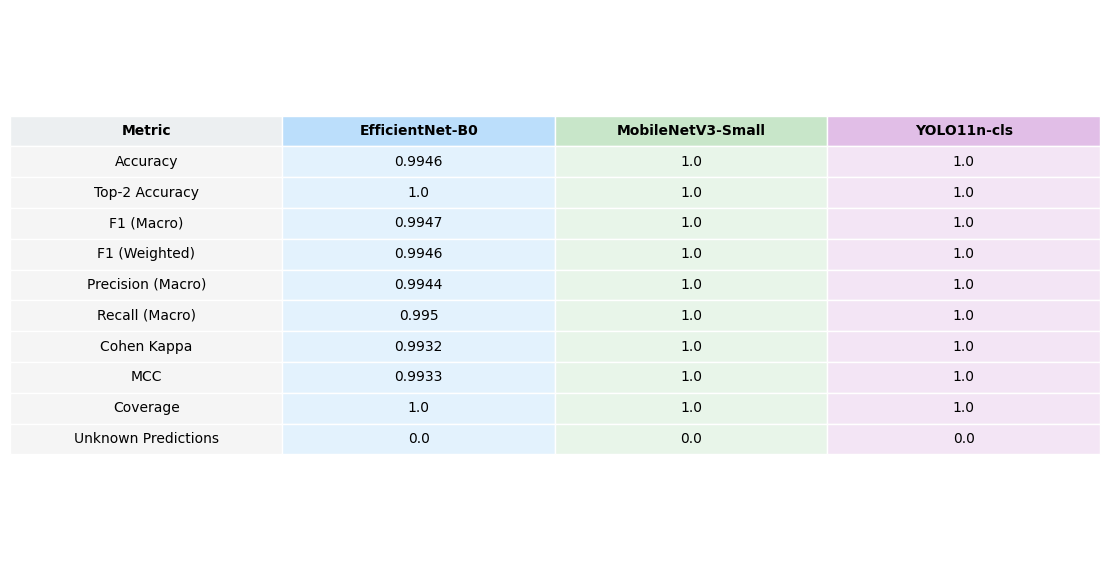

Summary table saved: /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/summary_table.png


In [ ]:
def build_summary_table(metrics_dict: dict) -> pd.DataFrame:
    """
    Assembles a clean summary DataFrame comparing all models
    across all evaluation metrics.
    """
    rows = []
    metric_keys = [
        'accuracy', 'top2_accuracy', 'f1_macro', 'f1_weighted',
        'precision_macro', 'recall_macro',
        'cohen_kappa', 'mcc', 'coverage', 'n_unknown'
    ]
    display_names = [
        'Accuracy', 'Top-2 Accuracy', 'F1 (Macro)', 'F1 (Weighted)',
        'Precision (Macro)', 'Recall (Macro)',
        'Cohen Kappa', 'MCC', 'Coverage', 'Unknown Predictions'
    ]

    for key, display in zip(metric_keys, display_names):
        row = {'Metric': display}
        for model_name, m in metrics_dict.items():
            val = m.get(key, 'N/A')
            row[model_name] = val
        rows.append(row)

    return pd.DataFrame(rows)


summary_df = build_summary_table(all_metrics)

print('\n--- Model Evaluation Summary ---')
print(summary_df.to_string(index=False))

summary_df.to_csv(
    os.path.join(RESULTS_DIR, 'evaluation_summary.csv'), index=False
)


def plot_summary_table(df: pd.DataFrame, save_path: str):
    model_cols = [c for c in df.columns if c != 'Metric']
    base_col_colors = ['#E3F2FD', '#E8F5E9', '#F3E5F5', '#FBE9E7', '#FFF8E1']
    base_header_colors = ['#BBDEFB', '#C8E6C9', '#E1BEE7', '#FFCCBC', '#FFECB3']

    col_colors = base_col_colors[:len(model_cols)]
    header_colors = ['#ECEFF1'] + base_header_colors[:len(model_cols)]

    n_rows = len(df)
    fig, ax = plt.subplots(figsize=(len(df.columns) * 2.8, n_rows * 0.48 + 1))
    ax.axis('off')

    cell_text = df.values.tolist()
    col_labels = df.columns.tolist()

    cell_colors = []
    for _ in range(n_rows):
        row_colors = ['#F5F5F5']
        for i in range(len(model_cols)):
            row_colors.append(col_colors[i % len(col_colors)])
        cell_colors.append(row_colors)

    tbl = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.5)

    for j in range(len(col_labels)):
        cell = tbl[(0, j)]
        cell.set_facecolor(header_colors[j])
        cell.set_text_props(weight='bold')
        cell.set_edgecolor('white')

    for i in range(1, n_rows + 1):
        for j in range(len(col_labels)):
            cell = tbl[(i, j)]
            cell.set_facecolor(cell_colors[i - 1][j])
            cell.set_edgecolor('white')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Summary table saved: {save_path}')


plot_summary_table(
    summary_df,
    save_path=os.path.join(RESULTS_DIR, 'summary_table.png')
)

# Section 19 - Parameters

## Install torchinfo

In [17]:
!pip install torchinfo -q

## Model Parameter Summary and Inference Speed

Profiles each model for total/trainable parameter counts, on-disk size, and per-image inference latency.

Saved: /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/model_profile_table.png


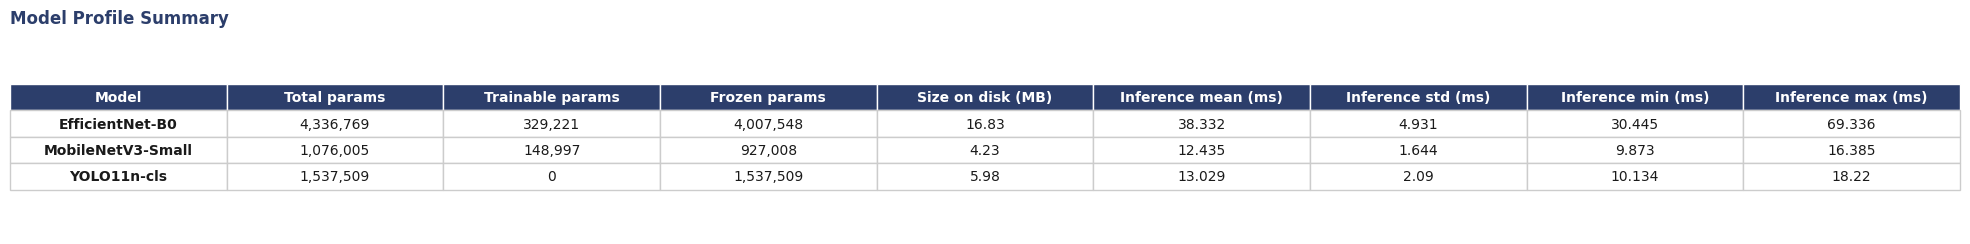

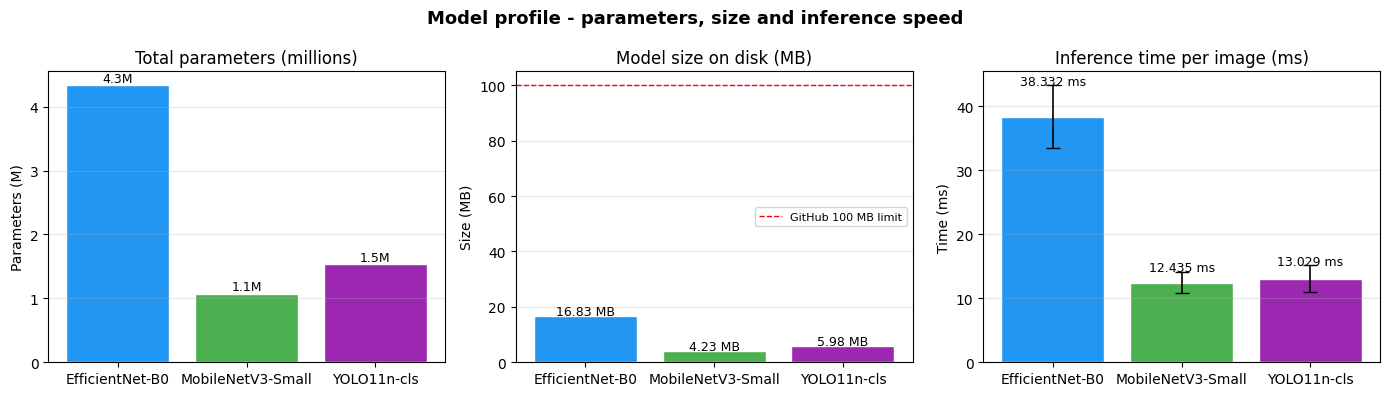

Model profile saved: /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/model_profile.png


In [18]:
# Section - Model Parameter Summary and Inference Speed

import time
from torchinfo import summary as ti_summary

def get_model_size_mb(model: nn.Module) -> float:
    tmp_path = '/tmp/tmp_model_size.pt'
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    return round(size_mb, 2)


def measure_inference_time(model: nn.Module, device: torch.device,
                           img_size: int = 224, n_runs: int = 200) -> dict:
    model.eval()
    dummy = torch.randn(1, 3, img_size, img_size).to(device)

    with torch.no_grad():
        for _ in range(20):
            _ = model(dummy)

    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model(dummy)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)

    return {
        'mean_ms':   round(float(np.mean(times)), 3),
        'std_ms':    round(float(np.std(times)),  3),
        'min_ms':    round(float(np.min(times)),  3),
        'max_ms':    round(float(np.max(times)),  3),
    }


def count_params(model: nn.Module) -> dict:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {'total': total, 'trainable': trainable, 'frozen': total - trainable}


def build_model_profile_table(model_entries: list, device: torch.device) -> pd.DataFrame:
    rows = []
    for model_name, model in model_entries:
        params  = count_params(model)
        size_mb = get_model_size_mb(model)
        timing  = measure_inference_time(model, device)

        rows.append({
            'Model':               model_name,
            'Total params':        f'{params["total"]:,}',
            'Trainable params':    f'{params["trainable"]:,}',
            'Frozen params':       f'{params["frozen"]:,}',
            'Size on disk (MB)':   size_mb,
            'Inference mean (ms)': timing['mean_ms'],
            'Inference std (ms)':  timing['std_ms'],
            'Inference min (ms)':  timing['min_ms'],
            'Inference max (ms)':  timing['max_ms'],
        })

    return pd.DataFrame(rows)


def plot_model_profile(df: pd.DataFrame, save_path: str):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle('Model profile - parameters, size and inference speed',
                 fontsize=13, fontweight='bold')

    colors = ['#2196F3', '#4CAF50', '#9C27B0', '#FF5722', '#FFC107']
    models = df['Model'].tolist()

    total_params = [int(v.replace(',', '')) for v in df['Total params']]
    plot_colors = colors[:len(models)]

    axes[0].bar(models, [p / 1e6 for p in total_params], color=plot_colors, edgecolor='white')
    axes[0].set_title('Total parameters (millions)')
    axes[0].set_ylabel('Parameters (M)')
    for i, v in enumerate(total_params):
        axes[0].text(i, v / 1e6 + 0.05, f'{v/1e6:.1f}M', ha='center', fontsize=9)
    axes[0].grid(True, alpha=0.3, axis='y')

    sizes = df['Size on disk (MB)'].tolist()
    axes[1].bar(models, sizes, color=plot_colors, edgecolor='white')
    axes[1].set_title('Model size on disk (MB)')
    axes[1].set_ylabel('Size (MB)')
    for i, v in enumerate(sizes):
        axes[1].text(i, v + 0.2, f'{v} MB', ha='center', fontsize=9)
    axes[1].axhline(100, color='red', linestyle='--', linewidth=1,
                    label='GitHub 100 MB limit')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3, axis='y')

    means = df['Inference mean (ms)'].tolist()
    stds  = df['Inference std (ms)'].tolist()
    axes[2].bar(models, means, yerr=stds, color=plot_colors, edgecolor='white',
                capsize=5, error_kw={'linewidth': 1.2})
    axes[2].set_title('Inference time per image (ms)')
    axes[2].set_ylabel('Time (ms)')
    for i, v in enumerate(means):
        axes[2].text(i, v + stds[i] + 0.1, f'{v} ms', ha='center', fontsize=9)
    axes[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Model profile saved: {save_path}')


model_entries = [
    ('EfficientNet-B0',   effnet_model),
    ('MobileNetV3-Small', mobilenet_model),
    ('YOLO11n-cls',       yolo_model.model.to(DEVICE) if hasattr(yolo_model, 'model') else effnet_model),
]

profile_df = build_model_profile_table(model_entries, DEVICE)

draw_single_table(profile_df, title='Model Profile Summary',
                  save_path=os.path.join(RESULTS_DIR, 'model_profile_table.png'))

plot_model_profile(
    profile_df,
    save_path=os.path.join(RESULTS_DIR, 'model_profile.png')
)

profile_df.to_csv(os.path.join(RESULTS_DIR, 'model_profile.csv'), index=False)

## External Class Evaluation

Runs all three models on external (out-of-domain) samples using the plain
80% sigmoid confidence threshold. No energy or embedding gates.
Samples whose max sigmoid score falls below the threshold are labelled **Unknown**.

Ensure that you updated EXTERNAL_ROOT path where you have external classes to test the rejection rate, ensure that each class structure follows the MVTec folder structures.

External classes found (12): ['bottle', 'cable', 'capsule', 'hazelnut', 'metal_nut', 'pill', 'screw', 'toothbrush', 'transistor', 'zipper', 'checkpoints', 'results']
  bottle: 30 sampled  (total available: 292)
  cable: 30 sampled  (total available: 374)
  capsule: 30 sampled  (total available: 351)
  hazelnut: 30 sampled  (total available: 501)
  metal_nut: 30 sampled  (total available: 335)
  pill: 30 sampled  (total available: 434)
  screw: 30 sampled  (total available: 480)
  toothbrush: 30 sampled  (total available: 102)
  transistor: 30 sampled  (total available: 313)
  zipper: 30 sampled  (total available: 391)
  checkpoints: 0 sampled  (total available: 0)
  results: 1 sampled  (total available: 1)

Total loaded: 301 samples from 12 classes
Saved: /content/drive/MyDrive/Colab Notebooks/ICT304/object_class/results/external_ood_evaluation.png


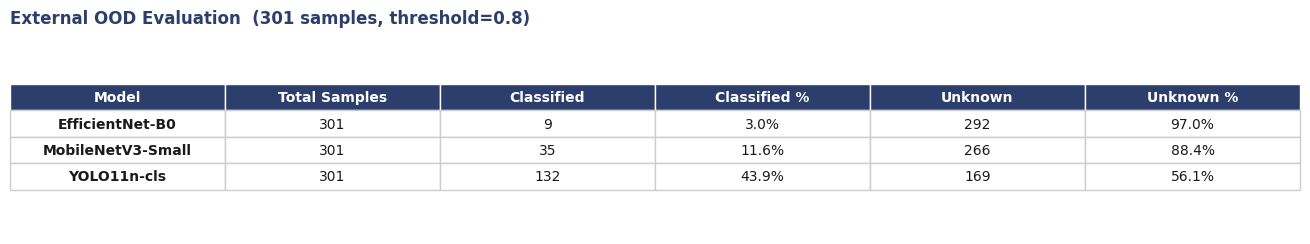

In [ ]:
def run_external_evaluation(samples: list):
    """
    Evaluate all three models on external (OOD) samples using only the
    80% sigmoid confidence threshold.  No energy or embedding gates.
    A prediction is accepted when max(sigmoid(logits)) >= CONFIDENCE_THRESHOLD,
    otherwise it is marked Unknown/Rejected.
    """
    results = {
        'EfficientNet-B0':   {'classified': 0, 'unknown': 0},
        'MobileNetV3-Small': {'classified': 0, 'unknown': 0},
        'YOLO11n-cls':       {'classified': 0, 'unknown': 0},
    }

    for entry in samples:
        img        = Image.open(entry['path']).convert('RGB')
        img_tensor = VAL_TRANSFORMS(img).unsqueeze(0).to(DEVICE)

        # EfficientNet-B0
        effnet_model.eval()
        with torch.no_grad():
            logits_eff = effnet_model(img_tensor)
        probs_eff = torch.sigmoid(logits_eff).cpu().numpy().flatten()
        if probs_eff.max() >= CONFIDENCE_THRESHOLD:
            results['EfficientNet-B0']['classified'] += 1
        else:
            results['EfficientNet-B0']['unknown'] += 1

        # MobileNetV3-Small
        mobilenet_model.eval()
        with torch.no_grad():
            logits_mob = mobilenet_model(img_tensor)
        probs_mob = torch.sigmoid(logits_mob).cpu().numpy().flatten()
        if probs_mob.max() >= CONFIDENCE_THRESHOLD:
            results['MobileNetV3-Small']['classified'] += 1
        else:
            results['MobileNetV3-Small']['unknown'] += 1

        # YOLO11n-cls
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))
        yolo_result = yolo_model(img_resized, verbose=False)[0]
        yolo_probs  = yolo_result.probs.data.cpu().numpy().flatten()
        if yolo_probs.max() >= CONFIDENCE_THRESHOLD:
            results['YOLO11n-cls']['classified'] += 1
        else:
            results['YOLO11n-cls']['unknown'] += 1

    total = len(samples)
    rows  = []
    for model_name, r in results.items():
        c, u = r['classified'], r['unknown']
        rows.append({
            'Model':            model_name,
            'Total Samples':    total,
            'Classified':       c,
            'Classified %':     f'{c / total * 100:.1f}%',
            'Unknown':          u,
            'Unknown %':        f'{u / total * 100:.1f}%',
        })

    ood_df = pd.DataFrame(rows)
    draw_single_table(
        ood_df,
        title     = f'External OOD Evaluation  ({total} samples, threshold={CONFIDENCE_THRESHOLD})',
        save_path = os.path.join(RESULTS_DIR, 'external_ood_evaluation.png')
    )

    return results


#---------------------------------------------------------
# Specify external classes directory
#---------------------------------------------------------

EXTERNAL_ROOT   = '/content/drive/MyDrive/Colab Notebooks/ICT304/dataset'
EXCLUDE_CLASSES = {'leather', 'carpet', 'tile', 'wood', 'grid'}

external_classes = [d for d in os.listdir(EXTERNAL_ROOT)
                    if os.path.isdir(os.path.join(EXTERNAL_ROOT, d))
                    and d not in SURFACE_CLASSES
                    and d not in EXCLUDE_CLASSES]

print(f'External classes found ({len(external_classes)}): {external_classes}')


def load_external_class_samples(root: str, surface_classes: list, n: int = 30) -> list:
    valid_exts = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
    EXCLUDE_DIR_NAMES = {'ground_truth', 'gt', 'checkpoints', 'results'}
    samples = []
    for cls in surface_classes:
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir):
            print(f'  [SKIP] {cls_dir} not found')
            continue
        all_images = []
        for dirpath, dirnames, fnames in os.walk(cls_dir):
            dirnames[:] = [d for d in dirnames if d not in EXCLUDE_DIR_NAMES]
            for f in fnames:
                if os.path.splitext(f)[1].lower() in valid_exts:
                    all_images.append(os.path.join(dirpath, f))
        picked = random.sample(all_images, min(n, len(all_images)))
        for p in picked:
            samples.append({'path': p, 'true_class': cls})
        print(f'  {cls}: {len(picked)} sampled  (total available: {len(all_images)})')
    print(f'\nTotal loaded: {len(samples)} samples from {len(surface_classes)} classes')
    return samples


external_samples      = load_external_class_samples(EXTERNAL_ROOT, external_classes, n=30)
external_eval_results = run_external_evaluation(external_samples)

## Upload Samples

Upon reviewing the results we can conclude that the samples needs to be in domain, which is our focus to reject any object outside of our scope. Additionally, we excect objects cropped correctly, since it is assumed images needs to be taken in controlled environmnets.

Upload only one image at a time

In [ ]:
# Section - Interactive Upload Inference

import io
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from PIL import Image
from IPython.display import display, clear_output

prediction_history = []

MODEL_REGISTRY = {
    'EfficientNet-B0':   {'type': 'pytorch', 'model': effnet_model},
    'MobileNetV3-Small': {'type': 'pytorch', 'model': mobilenet_model},
    'YOLO11n-cls':       {'type': 'yolo',    'model': yolo_model},
}

DEFAULT_SELECTED_MODELS = ['EfficientNet-B0', 'MobileNetV3-Small', 'YOLO11n-cls']


def run_single_model_inference(model_name: str, img: Image.Image) -> dict:
    """
    Run inference with sigmoid confidence threshold only.
    Predictions with max(sigmoid(logits)) < CONFIDENCE_THRESHOLD are
    labelled Unknown.
    """
    entry = MODEL_REGISTRY[model_name]

    if entry['type'] == 'yolo':
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))
        result      = entry['model'](img_resized, verbose=False)[0]
        probs       = result.probs.data.cpu().numpy().flatten()
        if len(probs) != len(SURFACE_CLASSES):
            probs = np.ones(len(SURFACE_CLASSES)) / len(SURFACE_CLASSES)
        pred_idx    = int(probs.argmax())
        confidence  = float(probs.max())
        pred_label  = SURFACE_CLASSES[pred_idx] if confidence >= CONFIDENCE_THRESHOLD else UNKNOWN_CLASS
        return {
            'label':           pred_label,
            'confidence':      confidence,
            'probs':           probs,
            'pred_idx':        pred_idx if pred_label != UNKNOWN_CLASS else -1,
            'accepted':        pred_label != UNKNOWN_CLASS,
            'decision_reason': 'sigmoid threshold'
        }

    # PyTorch models (EfficientNet-B0, MobileNetV3-Small)
    model      = entry['model']
    img_tensor = VAL_TRANSFORMS(img).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor)
        probs  = torch.sigmoid(logits).cpu().numpy().flatten()

    pred_idx   = int(probs.argmax())
    confidence = float(probs.max())
    pred_label = SURFACE_CLASSES[pred_idx] if confidence >= CONFIDENCE_THRESHOLD else UNKNOWN_CLASS

    return {
        'label':           pred_label,
        'confidence':      confidence,
        'probs':           probs,
        'pred_idx':        pred_idx if pred_label != UNKNOWN_CLASS else -1,
        'accepted':        pred_label != UNKNOWN_CLASS,
        'decision_reason': 'sigmoid threshold'
    }


def render_history():
    with output_area:
        clear_output(wait=True)

        selected_models = list(model_selector.value)
        print(f'Selected models      : {selected_models}')
        print(f'Confidence threshold : {CONFIDENCE_THRESHOLD}')

        if not prediction_history:
            print('No predictions yet. Upload one or more images above.')
            return

        for item_idx, entry in enumerate(prediction_history, start=1):
            img     = entry['image']
            results = entry['results']

            fig, axes = plt.subplots(
                len(selected_models), 2,
                figsize=(12, 4.2 * len(selected_models))
            )
            if len(selected_models) == 1:
                axes = np.array([axes])

            for row_idx, model_name in enumerate(selected_models):
                if model_name not in results:
                    continue

                res    = results[model_name]
                img_ax = axes[row_idx][0]
                bar_ax = axes[row_idx][1]

                img_ax.imshow(img)
                img_ax.axis('off')

                if res['label'] == UNKNOWN_CLASS:
                    color = '#9E9E9E'
                    title = f'{model_name} | UNKNOWN | {res["confidence"]:.1%}'
                else:
                    color = '#4CAF50'
                    title = f'{model_name} | {res["label"].upper()} | {res["confidence"]:.1%}'

                subtitle = f'Image {item_idx}: {entry["filename"]} | {res["decision_reason"]}'
                img_ax.set_title(title, fontsize=11, fontweight='bold', color=color, pad=8)
                img_ax.text(0.5, -0.05, subtitle, transform=img_ax.transAxes,
                            ha='center', fontsize=9, color='gray')

                bar_colors = ['#E0E0E0'] * len(SURFACE_CLASSES)
                if res['pred_idx'] >= 0:
                    bar_colors[res['pred_idx']] = color

                bars = bar_ax.barh(SURFACE_CLASSES, res['probs'],
                                   color=bar_colors, edgecolor='white', height=0.6)
                bar_ax.set_xlim(0, 1)
                bar_ax.set_xlabel('Confidence score')
                bar_ax.set_title('Class probabilities', fontsize=10)
                bar_ax.axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--',
                               linewidth=1.2, label=f'Threshold ({CONFIDENCE_THRESHOLD})')
                bar_ax.legend(fontsize=8)
                bar_ax.grid(True, alpha=0.3, axis='x')

                for bar, prob in zip(bars, res['probs']):
                    bar_ax.text(prob + 0.01, bar.get_y() + bar.get_height() / 2,
                                f'{prob:.3f}', va='center', fontsize=9)

            plt.tight_layout()
            plt.show()

        print('\n--- Prediction Log ---')
        for i, entry in enumerate(prediction_history, start=1):
            print(f'Image {i}: {entry["filename"]}')
            for model_name in selected_models:
                if model_name not in entry['results']: continue
                res = entry['results'][model_name]
                print(f'  - {model_name:<18} label={res["label"]:<10} '
                      f'conf={res["confidence"]:.4f}')


def on_upload(change):
    new_files = uploader.value
    if not new_files:
        return
    for filename, file_info in new_files.items():
        if any(e['filename'] == filename for e in prediction_history):
            continue
        raw = file_info['content']
        img = Image.open(io.BytesIO(raw)).convert('RGB')
        results = {m: run_single_model_inference(m, img) for m in model_selector.value}
        prediction_history.append({'filename': filename, 'image': img, 'results': results})
    render_history()


def on_clear(btn):
    prediction_history.clear()
    uploader.close()
    new_uploader = widgets.FileUpload(accept='image/*', multiple=True, description='Upload image(s)')
    new_uploader.observe(on_upload, names='value')
    upload_box.children = [new_uploader, clear_btn]
    globals()['uploader'] = new_uploader
    render_history()


model_selector = widgets.SelectMultiple(
    options=list(MODEL_REGISTRY.keys()),
    value=tuple(DEFAULT_SELECTED_MODELS),
    description='Models',
    layout=widgets.Layout(width='420px', height='120px')
)
uploader  = widgets.FileUpload(accept='image/*', multiple=True, description='Upload image(s)')
clear_btn = widgets.Button(description='Clear history', button_style='warning')

uploader.observe(on_upload, names='value')
clear_btn.on_click(on_clear)

output_area = widgets.Output()
upload_box  = widgets.HBox([uploader, clear_btn])

display(widgets.VBox([
    widgets.HTML('<h3>Upload an image and compare models</h3>'),
    model_selector,
    upload_box,
    output_area
]))

render_history()

According to all testings done, efficient net is chosen as it supports heavy default cases, and better rejection rate for unknown samples